# 推理模型与推理时计算

> 357 × 289 等于多少？问一个普通语言模型，它会立刻给你一个数字，而且经常是错的。问 DeepSeek-R1，它会先「思考」几百个 token 再作答，通常就是对的。两者的参数量可以相同，会的数学公式也一样，差别只在一件事：作答的那一刻，愿不愿意多花一点计算。
>
> 这一节就把这件事拆开看。先从 Chain-of-Thought（CoT）讲起，看「先写步骤再作答」为什么能提升准确率；再看 DeepSeek-R1 这类 thinking 模型怎么用强化学习把这种行为练进模型内部；最后讨论推理时算力——同一个模型，推理时多采样几次、多给一点思考预算，正确率还能往上走多少。

推理模型（reasoning model）指在给出最终答案之前，会先生成一段中间推理过程（思维链）的模型。让它具备这种能力有两条路线：训练侧，用强化学习把「先想再答」变成模型自己的行为；推理侧，不改模型，只在推理时多花算力。这一章的前半部分讲训练侧，后半部分讲推理侧。

## 本节要点

通过这一节的学习，以下问题应该能够回答：

1. 为什么普通 LLM 不擅长多步计算？
2. CoT 为什么能提升准确率？
3. thinking 模型的训练流程是什么？R1-Zero 做了什么实验？
4. 什么是 test-time scaling？Self-Consistency、pass@N、Best-of-N 各适合什么任务？
5. 怎么控制思考的开关和预算？自适应思考解决什么问题？

## 1. 从语言模型到推理模型

### 1.1 一次前向传播算不动的事

先看普通语言模型作答时内部发生了什么：

```text
用户: 357 × 289 = ?
普通 LLM: 输入 token → embedding → transformer × N 层 → 直接输出答案
```

**根本原因**：Transformer 的每一层都是固定计算量。不管问题是「1+1」还是「两个三位数相乘」，一次前向传播都只经过固定的层数，计算深度有限。让有限的深度一次算出 357 × 289，就像让你心算这道题——不是不可能，是容易错。

换成手算，你会列竖式分步来：

1. 357 × 200 = 71400
2. 357 × 80 = 28560
3. 357 × 9 = 3213
4. 71400 + 28560 + 3213 = 103173

每一步都足够简单，每一步的结果都交给下一步。LLM 也需要同样的「分步计算」过程——这就是 Chain-of-Thought（CoT）。下面先用一段真实计算看看差别。

In [1]:
# 真实计算演示：CoT 为什么有效
import numpy as np
import random

print("=== CoT 为什么有效 ===")
print()

target = 357 * 289

# 没有 CoT：要求一步算出
print("没有 CoT:")
print(f"  模型需要一步算出 357 × 289 = ?")
print(f"  正确答案: {target:,}")
np.random.seed(42)
guesses = np.random.randint(80000, 120000, size=5)
closest = guesses[np.argmin(np.abs(guesses - target))]
print(f"  模型只能「猜」: {closest:,} (差了 {abs(closest - target):,})")
print(f"  → 一步到位太难了！")
print()

# 有 CoT：分步计算
print("有 CoT (分步计算):")
result = 0
steps = []
for multiplier, label in [(200, "200"), (80, "80"), (9, "9")]:
    partial = 357 * multiplier
    result += partial
    steps.append(partial)
    print(f"  357 × {label} = {partial:,}")

total = sum(steps)
print(f"  {' + '.join(f'{s:,}' for s in steps)} = {total:,}")
print()
print(f"✅ CoT 结果: {total:,} == 正确答案 {target:,}")
print()
print("关键：每一步的计算结果都可以被后续步骤引用。")
print("这相当于用「生成 token 的时间」换「计算深度」。")

=== CoT 为什么有效 ===

没有 CoT:
  模型需要一步算出 357 × 289 = ?
  正确答案: 103,173
  模型只能「猜」: 95,795 (差了 7,378)
  → 一步到位太难了！

有 CoT (分步计算):
  357 × 200 = 71,400
  357 × 80 = 28,560
  357 × 9 = 3,213
  71,400 + 28,560 + 3,213 = 103,173

✅ CoT 结果: 103,173 == 正确答案 103,173

关键：每一步的计算结果都可以被后续步骤引用。
这相当于用「生成 token 的时间」换「计算深度」。


### 1.2 CoT：把步骤写出来，再给答案

CoT 的核心思想极其简单：**在 prompt 里示范「先写推理过程，再写答案」**。

```
没有 CoT 的 prompt:
  Q: 357 × 289 = ?
  A: 103173  ← 模型直接猜

有 CoT 的 prompt (Few-shot):
  Q: 123 × 45 = ?
  A: 123×40=4920, 123×5=615, 4920+615=5535。答案是 5535。
  
  Q: 357 × 289 = ?
  A:  ← 模型会模仿上面的格式，先写过程再给答案
```

**为什么有效？** 因为模型在生成推理过程时，每个中间步骤的结果都变成了后续步骤的「上下文」。
Transformer 的 attention 能看到前面算出的中间结果，从而基于它们继续推理。

本质上：**CoT 把「一次前向传播解决不了的问题」变成了「多次前向传播接力解决」**。

### 1.3 从 CoT 到 Thinking 模型：把草稿纸收起来

CoT 有一个问题：推理过程全部暴露给用户。用户不一定想看你的草稿纸。

Thinking 模型（思考模型）的定义：在训练阶段学会「先生成思维链、再给出答案」，并用专门的符号把草稿区和答案区分开的模型。它的做法就是把「草稿纸」和「最终答案」分开：

```text
用户看到的:
  Q: 357 × 289 = ?
  A: 103173

模型内部实际生成的:
  <think>
  357×200=71400
  357×80=28560
  357×9=3213
  71400+28560+3213=103173
  </think>
  103173
```

这里的 `<think>` 和 `</think>` 就是 thinking 符号。
它们像一对括号：中间是思考草稿，后面才是最终回答。

前端或 API 可以选择只展示 `</think>` 后面的答案，把中间草稿折叠或隐藏。

**本质**：Thinking 模型 = CoT 的工程化封装。思考过程还在，只是被特殊符号分区管理。

### 1.4 `<think>` 为什么是 special token

#### 为什么 `<think>` 不是普通文字？

你可能会想：`<think>` 不就是几个字符吗？模型输出这几个字符就行了？

不是这么简单。

如果 `<think>` 只是普通文字，可能出现三个问题：

1. **容易被 tokenizer 切碎**：`<think>` 可能变成 `<`、`think`、`>` 三个 token。
2. **结束边界不稳定**：模型可能在草稿里意外写出 `</think>`，导致前端提前结束 thinking。
3. **训练不好控制**：你很难稳定地区分 thinking 区间和 answer 区间。

所以一种更稳的做法是：把 `<think>` 和 `</think>` 加成 **special tokens**。但这不是唯一方案，有些模型也会使用普通字符串、chat template、API block 或单独字段来区分 reasoning 和 answer。

也就是说，它们要像 `<BOS>`、`<EOS>` 一样，有自己的独立 ID：

```text
<think>   -> 100
</think>  -> 101
```

这样模型生成 ID 100，就等于进入思考区间；生成 ID 101，就等于退出思考区间。

#### 怎么把新的 thinking 符号加入训练？

现代训练里，新增 `<think>` 这类符号一般分两种情况。

**情况 A：从零训练 tokenizer 和模型**

一开始就把这些符号放进 tokenizer 的 special token 列表：

```text
<BOS>、<EOS>、<PAD>、<think>、</think>
```

这样训练 tokenizer 时，它们不会被拆碎；训练模型时，它们也会像普通 token 一样学到 embedding。

**情况 B：在已有模型上继续训练**

这是更常见的路线。比如你拿一个开源基座模型，想让它学会新的 thinking 格式，通常要做 4 步：

1. **给 tokenizer 加符号**：把 `<think>`、`</think>` 加成 special tokens。
2. **扩模型 embedding**：tokenizer 词表变大，模型的 `Embedding` 和输出层也要变大。
3. **准备格式化数据**：样本里真的要有 `<think>...</think>`。
4. **继续 SFT / RL**：让模型通过 loss 或 reward 学会什么时候打开、什么时候关闭 thinking。

工程里常见的伪代码是：

```python
new_tokens = {"additional_special_tokens": ["<think>", "</think>"]}
num_added = tokenizer.add_special_tokens(new_tokens)
model.resize_token_embeddings(len(tokenizer))

# 然后用带 <think>...</think> 的数据继续训练
```

这一步很容易被误解：**加 token 只是给模型一支新笔，不等于它会写推理。**
真正让它学会 thinking 的，是后面的训练数据、loss mask、reward 设计。

In [1]:
# 用最小例子演示：新增 <think> 符号后的训练样本
vocab = {
    "<BOS>": 0,
    "<EOS>": 1,
    "<PAD>": 2,
    "用户": 3,
    "助手": 4,
    "答案": 5,
    "357": 6,
    "289": 7,
    "103173": 8,
}

new_symbols = ["<think>", "</think>"]
for symbol in new_symbols:
    if symbol not in vocab:
        vocab[symbol] = len(vocab)

train_tokens = [
    "<BOS>",
    "用户", "357", "289",
    "助手", "<think>", "357", "289", "103173", "</think>",
    "答案", "103173",
    "<EOS>",
]
train_ids = [vocab[token] for token in train_tokens]

print("新增符号:")
for symbol in new_symbols:
    print(f"  {symbol} -> ID {vocab[symbol]}")

print()
print("训练样本:")
print(train_tokens)
print()
print("训练 ID:")
print(train_ids)
print()
print("关键观察：模型不是听懂了 '<think>' 这个英文单词，")
print("而是在训练中学会 ID 9 和 ID 10 之间应该写推理草稿。")

新增符号:
  <think> -> ID 9
  </think> -> ID 10

训练样本:
['<BOS>', '用户', '357', '289', '助手', '<think>', '357', '289', '103173', '</think>', '答案', '103173', '<EOS>']

训练 ID:
[0, 3, 6, 7, 4, 9, 6, 7, 8, 10, 5, 8, 1]

关键观察：模型不是听懂了 '<think>' 这个英文单词，
而是在训练中学会 ID 9 和 ID 10 之间应该写推理草稿。


In [1]:
# ============================================================
# 演示：Special Token 是怎么被分词的
# ============================================================
print("=== Special Token vs 普通文字：分词对比 ===\n")

# 模拟 tokenizer 的行为 — 用一个简化的 BPE 风格 tokenizer
# 核心问题：<think> 如果只是普通文字，它是什么命运？

# 假设这是 tokenizer 的词表（简化版）
vocab = {
    "我": 1, "喜欢": 2, "吃": 3, "苹果": 4, "橘子": 5,
    "think": 7, "<": 9, ">": 10, "/": 11,
    "推理": 13, "过程": 14, "答案": 15, "是": 16,
    # ↓ 关键：如果设为 special token，会有唯一 ID
    # "<think>": 100,
    # "</think>": 101,
}

print("【词表】普通 token（不含 special token）:")
for k, v in sorted(vocab.items(), key=lambda x: x[1]):
    print(f"  '{k}' → {v}")
print()

# ========================================
# 场景 1：没有 special token 时
# ========================================
print("=" * 55)
print("场景 1：<think> 只是普通文字（没有加入词表）")
print("=" * 55)

def tokenize_plain(text, vocab):
    """模拟 BPE/word-level tokenizer，没有 special token 的情况"""
    tokens = []
    i = 0
    while i < len(text):
        # 按最长匹配找普通 token
        matched = None
        for word in sorted(vocab.keys(), key=len, reverse=True):
            if text[i:].startswith(word):
                matched = (word, vocab[word])
                break
        if matched:
            tokens.append(matched)
            i += len(matched[0])
        else:
            # 逐字符 fallback
            ch = text[i]
            tid = ord(ch) % 50 + 20  # 模拟 unknown token 的 id
            tokens.append((ch if ch != ' ' else '⎵', tid))
            i += 1
    return tokens

text = "我喜欢<think>推理过程</think>答案是苹果"
tokens_plain = tokenize_plain(text, vocab)

print(f"输入: {text}")
print(f"\n分词结果 ({len(tokens_plain)} 个 token):")
ids = []
for word, tid in tokens_plain:
    ids.append(tid)
    flag = "⚠️拆碎" if tid in [9,10,11] else ""
    print(f"  [{word:6s}] → ID {tid:3d} {flag}")

print(f"\nToken ID 序列: {ids}")
print(f"\n关键问题:")
print(f"  ❌ '<think>' 被切成 3 个 token: < think >   共 3 个 ID")
print(f"  ❌ 如果 thinking 内容里出现 '<'（如 x<5） → 混乱")
print(f"  ❌ 训练时无法用 token ID 精确定位 'thinking 从哪开始'")
print(f"  ❌ 模型要学 '恰好按顺序输出这 5 个 token' → 极难学会")

# ========================================
# 场景 2：添加 special token 后
# ========================================
print(f"\n{'='*55}")
print("场景 2：<think> 设为 Special Token（更稳的做法之一）")
print("=" * 55)

# 把 special token 加入词表
vocab_with_special = vocab.copy()
vocab_with_special["<think>"] = 100
vocab_with_special["</think>"] = 101

print("词表新增:")
print("  '<think>'  → 100  ★ special token")
print("  '</think>' → 101  ★ special token")
print()

def tokenize_with_special(text, vocab):
    """
    tokenizer 会先扫描 special token（最长匹配优先），
    再扫描普通 token。这是所有真实 tokenizer 的做法。
    """
    tokens = []
    i = 0
    while i < len(text):
        # Step 1：先匹配 special token（ID >= 100）
        matched = None
        for word in sorted(vocab.keys(), key=lambda x: (-len(x), x)):
            if text[i:].startswith(word):
                matched = (word, vocab[word])
                break
        if matched:
            tokens.append(matched)
            i += len(matched[0])
        else:
            ch = text[i]
            tokens.append((ch, ord(ch) % 50 + 20))
            i += 1
    return tokens

tokens_special = tokenize_with_special(text, vocab_with_special)

print(f"输入: {text}")
print(f"\n分词结果 ({len(tokens_special)} 个 token):")
ids_special = []
for word, tid in tokens_special:
    ids_special.append(tid)
    flag = "★ 特殊" if tid >= 100 else ""
    print(f"  [{word:12s}] → ID {tid:3d} {flag}")

print(f"\nToken ID 序列: {ids_special}")
print(f"Token 数量: {len(tokens_plain)} → {len(tokens_special)} 个")
print(f"\n关键优势:")
print(f"  ✅ '<think>' = 一个 token (ID=100)，不会被切碎")
print(f"  ✅ thinking 内部出现 '<' '>' 无影响（先匹配 special）")
print(f"  ✅ 检查 ID==100/101 即可精确定位 thinking 边界")
print(f"  ✅ 模型只需学会 '在合适位置输出 token 100'")

# ========================================
# 用真实 tokenizer 演示（如果 tiktoken 可用）
# ========================================
print(f"\n{'='*55}")
print("真实 tokenizer 的做法")
print("=" * 55)

try:
    import tiktoken
    
    # GPT-2 的 tokenizer（没有 think special token）
    enc = tiktoken.get_encoding("gpt2")
    plain_result = enc.encode("<think>")
    print(f"\nGPT-2 tokenizer 编码 '<think>':")
    print(f"  Token IDs: {plain_result}")
    print(f"  每个 token: {[enc.decode([t]) for t in plain_result]}")
    print(f"  → 被切成 {len(plain_result)} 个 token（因为 GPT-2 词表里没有 '<think>'）")
    
    # 说明真实做法
    print(f"\nDeepSeek-R1 / Qwen3 的做法:")
    print(f"  1. 在 tokenizer 词表中添加 special token:")
    print(f"     tokenizer.add_special_tokens({{'<think>': ..., '</think>': ...}})")
    print(f"  2. 模型 embedding 矩阵扩大一行（为新 token）")
    print(f"  3. 现在 '<think>' 就是一个完整的 token 了")
    
except ImportError:
    print("\n(未安装 tiktoken，跳过真实 tokenizer 演示)")
    print("pip install tiktoken 即可运行上述演示")
    print()
    print("以 GPT-4 的 cl100k_base 为例:")
    print("  '<think>' 如果没加入词表 → 可能被切成多个 BPE token")
    print("  加入词表后 → 1 个 token → 模型学习成本降低 5 倍")

print(f"\n总结: add_special_tokens() 是训练 thinking 模型的第一步。")

=== Special Token vs 普通文字：分词对比 ===

【词表】普通 token（不含 special token）:
  '我' → 1
  '喜欢' → 2
  '吃' → 3
  '苹果' → 4
  '橘子' → 5
  'think' → 7
  '<' → 9
  '>' → 10
  '/' → 11
  '推理' → 13
  '过程' → 14
  '答案' → 15
  '是' → 16

场景 1：<think> 只是普通文字（没有加入词表）
输入: 我喜欢<think>推理过程</think>答案是苹果

分词结果 (14 个 token):
  [我     ] → ID   1 
  [喜欢    ] → ID   2 
  [<     ] → ID   9 ⚠️拆碎
  [think ] → ID   7 
  [>     ] → ID  10 ⚠️拆碎
  [推理    ] → ID  13 
  [过程    ] → ID  14 
  [<     ] → ID   9 ⚠️拆碎
  [/     ] → ID  11 ⚠️拆碎
  [think ] → ID   7 
  [>     ] → ID  10 ⚠️拆碎
  [答案    ] → ID  15 
  [是     ] → ID  16 
  [苹果    ] → ID   4 

Token ID 序列: [1, 2, 9, 7, 10, 13, 14, 9, 11, 7, 10, 15, 16, 4]

关键问题:
  ❌ '<think>' 被切成 3 个 token: < think >   共 3 个 ID
  ❌ 如果 thinking 内容里出现 '<'（如 x<5） → 混乱
  ❌ 训练时无法用 token ID 精确定位 'thinking 从哪开始'
  ❌ 模型要学 '恰好按顺序输出这 5 个 token' → 极难学会

场景 2：<think> 设为 Special Token（更稳的做法之一）
词表新增:
  '<think>'  → 100  ★ special token
  '</think>' → 101  ★ special token

输入: 我喜欢<think>推理过程</think>答案是苹果

分词

### 1.5 训练时，thinking 部分的 loss 怎么算

有了 `<think>` 这种 special token，一个重要的问题出现了：

**训练时，thinking 部分的 token 要算 loss 吗？**

这有三种策略，各有优劣。我们先看一个具体例子：

```
完整的 assistant 输出 token 序列:
[<think>, 3, 1, 2, ×, 2, 0, 0, =, 7, 1, 4, 0, 0, </think>, 1, 0, 3, 1, 7, 3]
│←──────── thinking tokens ────────────→│←─ answer tokens ─→│
        14 个 token                             6 个 token
```

#### 策略对比

```
┌─────────────────────┬──────────────────┬──────────────────┬──────────────────┐
│                     │ 策略 A: Full Loss│ 策略 B: Answer   │ 策略 C: Selective│
│                     │ (全算 loss)      │ Only (只算答案)  │ Weighting(加权)  │
├─────────────────────┼──────────────────┼──────────────────┼──────────────────┤
│ thinking token 的   │       ✅ 算      │     ❌ 不算      │   🔶 算但降权    │
│ loss                │                  │                  │   (×0.1)         │
│ answer token 的     │       ✅ 算      │      ✅ 算       │     ✅ 算        │
│ loss                │                  │                  │                  │
│ special token 的    │       ✅ 算      │     ❌ 不算      │    ❌ 不算       │
│ loss (<think>等)  │                  │                  │                  │
├─────────────────────┼──────────────────┼──────────────────┼──────────────────┤
│ 优点                │ 简单直接         │ 只关心最终答案   │ 平衡两者         │
│                     │ 思考质量也被优化  │ 思考自由度高     │ 思考有引导但不   │
│                     │                  │                  │ 主导训练         │
├─────────────────────┼──────────────────┼──────────────────┼──────────────────┤
│ 缺点                │ 思考可能变成     │ 思考过程可能     │ 需要调权重超参   │
│                     │ 「表演」而非推理  │ 退化或乱写       │                  │
├─────────────────────┼──────────────────┼──────────────────┼──────────────────┤
│ 代表模型/场景        │ DeepSeek-R1     │ 早期 thinking    │ 部分 RL 实验     │
│                     │ (RL 阶段全算)   │ 实验             │                  │
└─────────────────────┴──────────────────┴──────────────────┴──────────────────┘
```

#### SFT 和 RL 阶段要分开理解

SFT 阶段可以讨论 full loss / answer-only / selective weighting：如果完全不监督 thinking 区间，模型可能只学到最终答案格式，thinking 行为不稳定。

RL 阶段不是普通 CE loss 「全算 token」。模型先采样回答，再根据结果 reward 优化策略；更长推理是否被强化，取决于 reward、格式约束、采样长度和训练稳定性。

但全算 loss 也有代价：模型可能学会「表演式思考」——
写一堆看起来像推理但实际无用的 token，只是因为这些 token 的 loss 低（模型很确定）。
RL 的结果奖励可以抑制一部分无用推理，但不能保证所有 thinking 都真实有效；仍需要格式检查、长度控制和任务评测。

#### 实现上怎么做？

核心是构造一个 **loss_mask**——一个和 labels 同样形状的 0/1 数组：

```python
# labels:   [100, 3, 1, 2, 11, ..., 101, 1, 0, 3, 1, 7, 3]
# loss_mask:[ 0,  1, 1, 1, 1,  ...,  0,  1, 1, 1, 1, 1, 1]
#             ↑ special token 不算          ↑ special token 不算
#
# 最终 loss = cross_entropy(logits, labels) * loss_mask
# → special token 位置 loss=0 → 不产生梯度
```

下面用代码完整实现这三种策略。

In [1]:
# ============================================================
# 完整实现：三种 Loss 策略的 loss_mask 构造
# ============================================================
import torch
import torch.nn.functional as F

import torch.nn as nn

print("=== Thinking 模型 Loss Mask 完整实现 ===\n")

# 模拟一个 batch 的 token 序列
# Special token ID: <think>=100, </think>=101
# 普通 token: 1-50
# PAD=0, IGNORE=-100（PyTorch 标准忽略值）
THINK_START = 100
THINK_END = 101
IGNORE = -100

# 模拟训练数据：两个样本的 labels
# 样本 1: <think> 3,1,2,11,2,0,0 </think> 1,0,3,1,7,3  ← 正常的 thinking→answer
# 样本 2: <think> 5,×,6,=,3,0 </think> 3,0          ← 简短的 thinking→answer
batch_labels = torch.tensor([
    [100,   3,   1,   2,  11,   2,   0,   0, 101,   1,   0,   3,   1,   7,   3,   0],
    [100,   5,  12,   6,  13,   3,   0, 101,   3,   0,   0,   0,   0,   0,   0,   0],
])  # shape: [2, 16]

# 模拟模型输出的 logits
VOCAB_SIZE = 200
logits = torch.randn(2, 16, VOCAB_SIZE)

print("Batch labels:")
print(batch_labels)
print()

# ============================================================
# 策略 A: Full Loss — 所有 token 都算 loss
# ============================================================
print("=" * 60)
print("策略 A: Full Loss（全算）")
print("=" * 60)

def make_full_loss_mask(labels, ignore_id=0):
    """最简单的 mask：只忽略 PAD token"""
    return (labels != ignore_id).float()

mask_full = make_full_loss_mask(batch_labels)
print("loss_mask (0=PAD不算, 1=算):")
print(mask_full.int())
print()

# 计算 loss
loss_full = F.cross_entropy(
    logits.view(-1, VOCAB_SIZE),
    batch_labels.view(-1),
    ignore_index=0,  # PAD 不参与
    reduction='none'
).view(2, 16)

print("每个位置的 loss:")
print(loss_full)
print()

total_full = loss_full.sum() / mask_full.sum()
print(f"Average loss (full): {total_full:.4f}")
print("→ thinking 和 answer 的每个 token 都优化")
print()

# ============================================================
# 策略 B: Answer Only — 只算 </think> 之后的 loss
# ============================================================
print("=" * 60)
print("策略 B: Answer Only（只算答案部分）")
print("=" * 60)

def make_answer_only_mask(labels, think_start=100, think_end=101, ignore_id=0):
    """
    只让 </think> 之后的 token 参与 loss 计算。
    逻辑：从每个序列中找到 think_end 的位置，之后的 token 才参与 loss。
    """
    mask = torch.zeros_like(labels, dtype=torch.float)

    for b in range(labels.shape[0]):
        # 找 </think> 的位置
        end_positions = (labels[b] == think_end).nonzero(as_tuple=True)[0]
        if len(end_positions) > 0:
            end_pos = end_positions[0].item()
            # </think> 之后（不含）到 EOS/PAD 之前
            for pos in range(end_pos + 1, labels.shape[1]):
                if labels[b, pos] == ignore_id:
                    break
                mask[b, pos] = 1.0
        # 如果没找到 think_end → 整个序列都可能是非 thinking 模式 → 全算

    return mask

mask_answer_only = make_answer_only_mask(batch_labels)
print("loss_mask (0=不算, 1=算):")
print(mask_answer_only.int())
print()

# 标注哪些 token 属于 thinking，哪些属于 answer
print("Token 标注 (T=thinking, A=answer, S=special, P=PAD):")
for b in range(2):
    row = ""
    for pos in range(16):
        tid = batch_labels[b, pos].item()
        if tid == 0:
            row += " P "
        elif tid == 100:
            row += "[S "
        elif tid == 101:
            row += " S]"
        elif mask_answer_only[b, pos] == 1:
            row += " A "
        else:
            row += " T "
    print(f"  样本{b}: {row}")
print()

# 构造 masked labels：不参与 loss 的位置设为 IGNORE
labels_masked_B = batch_labels.clone()
labels_masked_B[mask_answer_only == 0] = IGNORE

loss_answer_only = F.cross_entropy(
    logits.view(-1, VOCAB_SIZE),
    labels_masked_B.view(-1),
    ignore_index=IGNORE,
)
print(f"Average loss (answer only): {loss_answer_only:.4f}")
print("→ 只有 answer token 被优化，thinking 自由发挥")
print()

# ============================================================
# 策略 C: Selective Weighting — thinking 降权
# ============================================================
print("=" * 60)
print("策略 C: Selective Weighting（thinking 降权 ×0.1）")
print("=" * 60)

def make_selective_weight_mask(labels, think_start=100, think_end=101,
                                thinking_weight=0.1, ignore_id=0):
    """
    thinking token 和 answer token 都算 loss，但权重不同：
    - thinking token: weight = 0.1
    - answer token:   weight = 1.0
    - special token:  不算
    """
    weight_mask = torch.zeros_like(labels, dtype=torch.float)

    for b in range(labels.shape[0]):
        in_thinking = False
        for pos in range(labels.shape[1]):
            tid = labels[b, pos].item()

            if tid == think_start:
                in_thinking = True
                continue  # special token 本身不算
            elif tid == think_end:
                in_thinking = False
                continue  # special token 本身不算
            elif tid == ignore_id:
                break  # PAD 不算

            if in_thinking:
                weight_mask[b, pos] = thinking_weight  # thinking: 0.1
            else:
                weight_mask[b, pos] = 1.0               # answer: 1.0

    return weight_mask

weight_mask = make_selective_weight_mask(batch_labels)
print("权重矩阵:")
for b in range(2):
    print(f"  样本{b}: {[f'{w:.1f}' for w in weight_mask[b].tolist()]}")
print()

# 加权 loss
loss_per_token = F.cross_entropy(
    logits.view(-1, VOCAB_SIZE),
    batch_labels.view(-1),
    ignore_index=0,
    reduction='none'
).view(2, 16)

weighted_loss = (loss_per_token * weight_mask).sum() / weight_mask.sum()
print(f"Average loss (selective weighting): {weighted_loss:.4f}")
print("→ thinking 有 10% 的优化信号，answer 有 100%")

# ============================================================
# 三种策略对比
# ============================================================
print(f"\n{'='*60}")
print("三种策略对比总结")
print("=" * 60)
print(f"""
  ┌──────────────────┬──────────┬──────────┬──────────┐
  │                  │ Full Loss│Answer Only│Selective │
  ├──────────────────┼──────────┼──────────┼──────────┤
  │ Avg Loss         │ {total_full:.4f}   │ {loss_answer_only:.4f}   │ {weighted_loss:.4f}   │
  │ thinking 被优化   │    ✅    │    ❌    │   🔶0.1  │
  │ answer 被优化     │    ✅    │    ✅    │    ✅    │
  │ 思考不会退化      │    ✅    │    ❌    │    ✅    │
  │ 实现复杂度        │   低     │   中     │   中     │
  └──────────────────┴──────────┴──────────┴──────────┘
""")

print("实际训练中怎么选？")
print("  SFT 阶段 → 通常用 Answer Only（让模型先学会格式）")
print("  RL 阶段 → 通常用 Full Loss（DeepSeek-R1 的做法）")
print("  混合阶段 → 用 Selective Weighting 做平滑过渡")
print()
print("但所有策略的共同点：special token 本身（<think>/</think>）不算 loss。")
print("因为这些 token 只是标记，它们的「预测」没有意义。")

=== Thinking 模型 Loss Mask 完整实现 ===

Batch labels:
tensor([[100,   3,   1,   2,  11,   2,   0,   0, 101,   1,   0,   3,   1,   7,
           3,   0],
        [100,   5,  12,   6,  13,   3,   0, 101,   3,   0,   0,   0,   0,   0,
           0,   0]])

策略 A: Full Loss（全算）
loss_mask (0=PAD不算, 1=算):
tensor([[1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0],
        [1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0]], dtype=torch.int32)

每个位置的 loss:
tensor([[5.8381, 5.4087, 6.3242, 6.6912, 6.1452, 5.4167, 0.0000, 0.0000, 4.8765,
         5.1861, 0.0000, 3.8398, 6.9319, 4.9337, 5.9232, 0.0000],
        [6.4174, 6.1325, 6.3639, 6.3578, 6.2013, 4.9956, 0.0000, 7.3602, 6.9956,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]])

Average loss (full): 5.9170
→ thinking 和 answer 的每个 token 都优化

策略 B: Answer Only（只算答案部分）
loss_mask (0=不算, 1=算):
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0]], dtype=torch.int32)

Token 标注 (

## 2. R1-Zero：纯强化学习推理

Thinking 模型「先想再答」的行为是怎么训练出来的？DeepSeek-R1 的技术报告给出了一条完整路线，其中包含一个激进的实验：完全跳过 SFT，只用强化学习训练推理能力。这个实验叫 R1-Zero。先看完整流程，再看 R1-Zero。

### 2.1 R1 的完整训练流程

训练一个 thinking 模型分四步：

```
Step 1: 冷启动 SFT
  收集几千条「带思考过程」的高质量数据
  格式: Q → thinking... → A
  用这些数据做监督微调，让模型学会「先想再说」的格式

Step 2: RL 推理训练（核心！）
  用强化学习训练模型的推理能力
  奖励信号:
    - 答案正确 → +1
    - 答案错误 → -1
    - 格式正确（有 thinking 标签）→ +0.1
    - 语言一致（thinking 和 answer 同语言）→ +0.1
  模型自己探索更好的推理路径

Step 3: 拒绝采样 + SFT
  用训练好的模型生成大量「问题→思考→答案」数据
  只保留答案正确的样本
  用这些高质量数据再做一轮 SFT

Step 4: 全场景 RL
  在更多类型的数据上做 RL（有用性、安全性等）
  让模型不仅会推理，还能好好聊天
```

**最关键的是 Step 2**：RL 让模型自己探索推理策略，而不是死记硬背人类的推理过程。

### 2.2 R1-Zero：跳过 SFT，直接上 RL

R1-Zero 是报告里的一个对照实验：不做冷启动 SFT，直接在基座模型上做强化学习。

它成立的前提是任务**可验证**。数学题和代码题有一个共同点——答案对不对可以用规则判断：

- 数学题：从模型输出里提取最终答案，和标准答案比对
- 代码题：运行测试用例，通过就是通过，失败就是失败

有了这种奖励信号，既不需要人工标注偏好，也不需要示范数据。奖励函数可以写得非常简单：

```text
reward = 正确性奖励 + 格式奖励
  正确性: 提取出的答案 == 标准答案 → +1，否则 0
  格式:   输出包含 <think>...</think> 结构 → +0.1
```

然后对每道题采样多条回答（温度调高，保证多样性），强化高奖励的回答，抑制低奖励的回答。没有人教模型「怎么想」，推理策略全靠它自己在试错中发现。

下面实现这个规则化奖励函数，看它对几条模型输出的打分。

In [ ]:
# 规则化奖励：对一条模型输出打分
# 这是 R1-Zero 在数学题上用的奖励类型：不需要人工标注，纯规则判断
import re

import matplotlib.pyplot as plt


def extract_answer(completion):
    """从模型输出中提取最终答案：取 </think> 之后的最后一个数字"""
    tail = completion.split("</think>")[-1]
    nums = re.findall(r"-?\d+(?:\.\d+)?", tail)
    return float(nums[-1]) if nums else None


def rule_reward(completion, ground_truth):
    """返回奖励的分项和总和：正确性 +1.0，格式 +0.1"""
    r = {"correct": 0.0, "format": 0.0}
    pred = extract_answer(completion)
    if pred is not None and abs(pred - ground_truth) < 1e-6:
        r["correct"] = 1.0
    if "<think>" in completion and "</think>" in completion:
        r["format"] = 0.1
    r["total"] = r["correct"] + r["format"]
    return r


# 对问题 15 + 27 = ? 采样到的几条输出（模拟 rollout）
samples = [
    {"text": "<think>15+20=35, 35+7=42</think>\n42",
     "label": "答案对，格式对"},
    {"text": "15+20=35, 35+7=42\n42",
     "label": "答案对，没有格式"},
    {"text": "15+27=41\n41",
     "label": "答案错，没有格式"},
    {"text": "the answer is 42",
     "label": "答案对，没有格式"},
    {"text": "<think>15+30=45, 45-3=42\n检查: 42-15=27，正确</think>\n42",
     "label": "答案对，格式对，含检查"},
]
ground_truth = 42.0

print("=== 规则化奖励打分（问题: 15 + 27 = ?）===\n")
rewards = []
for s in samples:
    r = rule_reward(s["text"], ground_truth)
    rewards.append(r)
    print(f"  {s['label']}")
    print(f"    正确性 {r['correct']:+.1f} + 格式 {r['format']:+.1f}"
          f" = {r['total']:+.1f}")
print()

# 可视化：每条输出的奖励分项
fig, ax = plt.subplots(figsize=(7, 3.5))
idx = range(1, len(rewards) + 1)
correct = [r["correct"] for r in rewards]
fmt = [r["format"] for r in rewards]
ax.bar(idx, correct, label="correctness", color="steelblue")
ax.bar(idx, fmt, bottom=correct, label="format", color="darkorange")
ax.set_xlabel("Sampled completion")
ax.set_ylabel("Reward")
ax.set_title("Rule-based reward breakdown (R1-Zero style)")
ax.set_xticks(list(idx))
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.show()

print("关键观察：正确性奖励占主导（1.0），格式奖励只有 0.1。")
print("  这个配比防止模型只学会输出标签、不学会解题。")
print("  RL 会强化高奖励输出，「怎么想」由模型自己探索出来。")

### 2.3 训练中自己学会的行为：aha moment

DeepSeek-R1 的报告记录了一个有趣的现象：R1-Zero 在训练过程中，自发出现了没人教过的行为，比如「重新检查」：

```text
模型的思考过程（报告中的例子）:
  我认为答案是 42...
  等等，让我重新检查一下...
  不对，我前面的推理有问题。重新算: 15+20=35, 35+7=42。
  验证: 42-27=15，正确。答案是 42。
```

报告把这个现象叫 aha moment。准确的理解是：在可验证任务上，奖励信号持续偏好更长、会自我检查的推理轨迹，这类行为在探索中被逐渐固定下来。这不等于模型像人一样「理解了自己」，但检查和回溯这类行为确实被强化出来了。

下面用一个小实验模拟这个过程：对比 RL 训练初期、中期、后期三个阶段的输出，看「会检查」的回答如何获得更高奖励。

In [1]:
# 模拟 RL 训练中「反思行为」的涌现
print("=== RL 训练中的反思行为涌现 ===")
print()

def evaluate_reasoning(reasoning, correct_answer):
    """评估推理过程，返回 (答案, 是否正确, 奖励)"""
    import re
    numbers = re.findall(r'[\d.]+', reasoning)
    answer = float(numbers[-1]) if numbers else None
    correct = (answer == correct_answer)

    reward = 1.0 if correct else -1.0
    steps = reasoning.count('+') + reasoning.count('-') + reasoning.count('×') + reasoning.count('=')
    reward += min(steps * 0.05, 0.2)
    has_check = any(w in reasoning for w in ['验证', '检查', '确认', '重新', '不对'])
    if has_check and correct:
        reward += 0.15
    return answer, correct, reward

correct_answer = 42.0
stages = [
    ("训练初期", [
        "15+27=41",
        "15+27=44",
        "15+27=39",
    ]),
    ("训练中期（开始反思）", [
        "15+27=41... 不对，重新算。15+20=35, 35+7=42。验证：42-27=15 ✓",
        "15+20=35, 35+7=42",
        "10+20=30, 5+7=12, 30+12=42。确认正确。",
    ]),
    ("训练后期（稳定推理）", [
        "15+20=35, 35+7=42。验证：42-27=15 ✓",
        "先算 15+20=35，再加 7=42。检查：42-15=27 ✓",
        "15+27: 拆分为 15+20=35, 35+7=42。验证 42-27=15, 正确。",
    ]),
]

for stage_name, outputs in stages:
    print(f"📋 {stage_name}:")
    total_reward = 0
    for reasoning in outputs:
        answer, correct, reward = evaluate_reasoning(reasoning, correct_answer)
        status = '✅' if correct else '❌'
        total_reward += reward
        print(f"  {status} {reasoning[:60]}...")
        print(f"     答案={answer}, 奖励={reward:+.2f}")
    avg_reward = total_reward / len(outputs)
    print(f"  平均奖励: {avg_reward:+.2f}")
    print()

print("趋势: 初期猜测为主 → 中期偶然反思(奖励高) → 后期反思成为习惯")
print("这就是涌现行为：没有人教模型要反思，是 RL 奖励让它自己发现的。")

=== RL 训练中的反思行为涌现 ===

📋 训练初期:
  ❌ 15+27=41...
     答案=41.0, 奖励=-0.90
  ❌ 15+27=44...
     答案=44.0, 奖励=-0.90
  ❌ 15+27=39...
     答案=39.0, 奖励=-0.90
  平均奖励: -0.90

📋 训练中期（开始反思）:
  ❌ 15+27=41... 不对，重新算。15+20=35, 35+7=42。验证：42-27=15 ✓...
     答案=15.0, 奖励=-0.80
  ✅ 15+20=35, 35+7=42...
     答案=42.0, 奖励=+1.20
  ✅ 10+20=30, 5+7=12, 30+12=42。确认正确。...
     答案=42.0, 奖励=+1.35
  平均奖励: +0.58

📋 训练后期（稳定推理）:
  ❌ 15+20=35, 35+7=42。验证：42-27=15 ✓...
     答案=15.0, 奖励=-0.80
  ❌ 先算 15+20=35，再加 7=42。检查：42-15=27 ✓...
     答案=27.0, 奖励=-0.80
  ❌ 15+27: 拆分为 15+20=35, 35+7=42。验证 42-27=15, 正确。...
     答案=15.0, 奖励=-0.80
  平均奖励: -0.80

趋势: 初期猜测为主 → 中期偶然反思(奖励高) → 后期反思成为习惯
这就是涌现行为：没有人教模型要反思，是 RL 奖励让它自己发现的。


### 2.4 R1-Zero 暴露的问题：为什么还要冷启动 SFT

纯 RL 是有代价的。报告承认，R1-Zero 在训练中存在几个问题：

| 问题 | 表现 |
|:---|:---|
| 语言混杂 | 思维链里中英文频繁切换，可读性差 |
| 格式不稳定 | 思考内容难以解析，前端难以展示 |
| 早期探索效率低 | 基座模型没见过「先想再答」的格式，前期全靠乱试 |

所以正式版 R1 在 RL 之前加回了冷启动 SFT：先用少量高质量的「问题 → 思考 → 答案」数据教会模型基本格式，再用 RL 提升推理内容。两个阶段的分工很清楚：

- **SFT 解决形式**：思考应该长什么样
- **RL 解决内容**：怎么想才对

R1-Zero 的价值在于证明：推理能力可以只靠 RL 被激发出来。完整 R1 的价值在于工程上的取舍：加回 SFT，让这条路走得稳。

## 3. Test-Time Scaling

缩放定律一节讲的是训练时算力扩展：模型更大、数据更多，效果更好。Thinking 模型也是训练侧的投入——用 RL 把推理能力练进权重。

还有一类方法完全不碰模型权重：**在推理时多花算力，换更高的正确率**。这个方向统称 test-time scaling（推理时扩展）。o1 的成功不只来自训练 thinking 模型，推理时的大量计算同样是关键。

常见手段分三类，下面逐个看：

| 手段 | 核心思想 |
|:---|:---|
| 多采样，投票决定 | 不同推理链犯的错不一样，多数票更可靠 |
| 多采样，挑最好的 | 用打分模型选出质量最高的一条 |
| 多采样，至少对一次 | 只要有一次答对就算成功（可验证任务） |

### 3.1 Self-Consistency：一道题多问几次，投票决定

CoT 有一个问题：**模型可能会在某条推理链上犯错**。
同样一道数学题，你问模型 5 次（temperature > 0），它可能给出 3 种不同的推理过程和答案。

**Self-Consistency 的核心思想**：
```
同一道题 → 采样 N 条不同的 CoT 推理链 → 对最终答案投票 → 得票最多的就是最终答案
```

**为什么有效？**

直觉：你拿一道难题问 5 个同学——
- 每个同学都可能在某一步想歪
- 但不同同学**犯不同错误的概率高，犯相同错误的概率低**
- 正确答案只有一个，在多条正确/部分正确的推理链中出现的频率最高

数学上：如果单条推理链的正确率是 p，N 条链中大多数正确的概率随 N 增长：
```
p=0.6, N=1: 正确率 60%
p=0.6, N=5: 至少 3 条正确的概率 = C(5,3)p^3(1-p)^2 + ... ≈ 68%
p=0.7, N=5: 至少 3 条正确的概率 ≈ 84%  ← 提升显著！
```

**不做什么**：不需要重新训练模型，不需要改模型架构，只需要在推理时**多采样 + 投票**。

下面用一个模拟演示全过程：

In [1]:
# ============================================================
# Self-Consistency 演示：同一道题，5 条推理链，投票选答案
# ============================================================
import random
random.seed(42)

print("=" * 70)
print("题目：小明有 15 个苹果，给了小红 3 个，又买了 8 个，")
print("      然后吃掉 2 个，最后把剩下的一半给了小刚。")
print("      小明现在还有几个苹果？")
print("=" * 70)

# 模拟 5 条不同的推理链（模拟模型在 temperature > 0 时的不同采样）
# 每条链展示「推理过程」+「最终答案」

reasoning_chains = [
    {
        "id": 1,
        "reasoning": [
            "Step 1: 初始有 15 个",
            "Step 2: 给小红 3 个 → 15 - 3 = 12 个",
            "Step 3: 又买了 8 个 → 12 + 8 = 20 个",
            "Step 4: 吃掉 2 个 → 20 - 2 = 18 个",
            "Step 5: 把一半给小刚 → 18 / 2 = 9 个",
        ],
        "answer": 9,
        "correct": True
    },
    {
        "id": 2,
        "reasoning": [
            "Step 1: 初始有 15 个",
            "Step 2: 给小红 3 个 → 15 - 3 = 12 个",
            "Step 3: 又买了 8 个 → 12 + 8 = 20 个",
            "Step 4: 吃掉 2 个 → 20 - 2 = 18 个",
            "Step 5: 一半给小刚 → 18 / 2 = 9 个",
        ],
        "answer": 9,
        "correct": True
    },
    {
        "id": 3,
        "reasoning": [
            "Step 1: 初始有 15 个",
            "Step 2: 给小红 3 个 → 15 - 3 = 12 个",
            "Step 3: 又买了 8 个 → 12 + 8 = 20 个",
            "Step 4: 吃掉 2 个 → 20 - 2 = 18 个",
            "Step 5: 把剩下的一半给小刚 → 剩下 18 - 9 = 9 个",  # 推理对，答案也对
        ],
        "answer": 9,
        "correct": True
    },
    {
        "id": 4,
        "reasoning": [
            "Step 1: 初始有 15 个",
            "Step 2: 给小红 3 个 → 15 - 3 = 12 个",
            "Step 3: 又买了 8 个 → 12 + 8 = 20 个",
            "Step 4: 吃掉 2 个 → 20 - 2 = 18 个",
            "Step 5: 忘了除以 2！→ 答案 18 个",  # ← 忘了最后一步！
        ],
        "answer": 18,
        "correct": False
    },
    {
        "id": 5,
        "reasoning": [
            "Step 1: 初始有 15 个",
            "Step 2: 给小红 3 个，买 8 个 → 总数 15 - 3 + 8 = 20 个",
            "Step 3: 吃掉 2 个 → 20 - 2 = 18 个",
            "Step 4: 一半给小刚 → 给 18/2 = 9 个，自己剩 9 个",
        ],
        "answer": 9,
        "correct": True
    },
]

# 打印每条推理链
for chain in reasoning_chains:
    print(f"\n--- 推理链 #{chain['id']} ---")
    for step in chain['reasoning']:
        print(f"  {step}")
    status = "✓ 正确" if chain['correct'] else "✗ 错误"
    print(f"  答案: {chain['answer']} 个苹果  {status}")

# ============================================================
# 多数投票
# ============================================================
print(f"\n{'=' * 70}")
print("投票环节")
print(f"{'=' * 70}")

from collections import Counter
answers = [c['answer'] for c in reasoning_chains]
vote_counts = Counter(answers)

for ans, count in vote_counts.most_common():
    correct_mark = "✓" if ans == 9 else "✗"
    bar = "█" * count
    print(f"  答案 {ans} 个: {count} 票 {bar} {correct_mark}")

winner = vote_counts.most_common(1)[0][0]
winner_is_correct = (winner == 9)

print(f"\n  🏆 最终答案（多数投票）: {winner} 个苹果")
print(f"     是否正确: {'✓ 正确！' if winner_is_correct else '✗ 错误'}")

# ============================================================
# 对比：单次 vs Self-Consistency
# ============================================================
print(f"\n{'=' * 70}")
print("对比分析")
print(f"{'=' * 70}")
print(f"  单次采样（随机取一条）: 正确率 = 4/5 = 80%")
print(f"  Self-Consistency (5 条投票): 正确率 = 100%（这次全都对了！）")
print(f"")
print(f"  关键洞察:")
print(f"  - 推理链 #4 在最后一步犯了错（忘了除以 2）")
print(f"  - 但其他 4 条链都对了，投票结果 = 9（正确）")
print(f"  - Self-Consistency 把那条错误的「吞掉了」！")
print(f"")
print(f"  这就是 Self-Consistency 的力量:")
print(f"  「少数服从多数」——一条链犯错没关系，多条链一起不会犯同样的错。")

题目：小明有 15 个苹果，给了小红 3 个，又买了 8 个，
      然后吃掉 2 个，最后把剩下的一半给了小刚。
      小明现在还有几个苹果？

--- 推理链 #1 ---
  Step 1: 初始有 15 个
  Step 2: 给小红 3 个 → 15 - 3 = 12 个
  Step 3: 又买了 8 个 → 12 + 8 = 20 个
  Step 4: 吃掉 2 个 → 20 - 2 = 18 个
  Step 5: 把一半给小刚 → 18 / 2 = 9 个
  答案: 9 个苹果  ✓ 正确

--- 推理链 #2 ---
  Step 1: 初始有 15 个
  Step 2: 给小红 3 个 → 15 - 3 = 12 个
  Step 3: 又买了 8 个 → 12 + 8 = 20 个
  Step 4: 吃掉 2 个 → 20 - 2 = 18 个
  Step 5: 一半给小刚 → 18 / 2 = 9 个
  答案: 9 个苹果  ✓ 正确

--- 推理链 #3 ---
  Step 1: 初始有 15 个
  Step 2: 给小红 3 个 → 15 - 3 = 12 个
  Step 3: 又买了 8 个 → 12 + 8 = 20 个
  Step 4: 吃掉 2 个 → 20 - 2 = 18 个
  Step 5: 把剩下的一半给小刚 → 剩下 18 - 9 = 9 个
  答案: 9 个苹果  ✓ 正确

--- 推理链 #4 ---
  Step 1: 初始有 15 个
  Step 2: 给小红 3 个 → 15 - 3 = 12 个
  Step 3: 又买了 8 个 → 12 + 8 = 20 个
  Step 4: 吃掉 2 个 → 20 - 2 = 18 个
  Step 5: 忘了除以 2！→ 答案 18 个
  答案: 18 个苹果  ✗ 错误

--- 推理链 #5 ---
  Step 1: 初始有 15 个
  Step 2: 给小红 3 个，买 8 个 → 总数 15 - 3 + 8 = 20 个
  Step 3: 吃掉 2 个 → 20 - 2 = 18 个
  Step 4: 一半给小刚 → 给 18/2 = 9 个，自己剩 9 个
  答案: 9 个苹果  ✓ 正确

投票环

#### Self-Consistency 和 Thinking 模型的关系

Self-Consistency 和后面要讲的 Thinking 模型（o1、R1）有本质区别：

| | Self-Consistency | Thinking 模型 |
|------|---------|-------|
| **怎么做** | 推理时多次采样 + 投票 | 训练时就学会"自己反思" |
| **成本** | N 倍推理成本（采样 N 次） | 1 次推理，但内部思考很长 |
| **需要训练吗** | 不需要 | 需要（RL 训练） |
| **关键能力** | 多样性采样 | 自我验证、纠错、回溯 |

**本质上**：
- Self-Consistency 是**外部**纠错——靠多次采样来"碰"正确答案
- Thinking 模型是**内部**纠错——在一条推理链里自己检查、自己改

后者更难训练，但推理时更高效（不需要重复采样）。
R1 一类模型的 self-verification 更适合理解为「在单条较长推理链中做检查和回溯」。它和 Self-Consistency 都利用了多步/多样信息，但机制不同，不能简单等同。Self-Consistency 参考：[Wang et al. 2022](https://arxiv.org/abs/2203.11171)。

### 3.2 pass@N：可验证任务上，看「至少对一次」

#### 实证曲线：在两位数加法上测 pass@N

后面要讲的 Best-of-N 需要 RM 给回答打分。如果任务**可验证**——数学题、代码题、24 点——就不需要 RM：对就是对，错就是错。这时 Best-of-N 变成一个更干净的问题：采样 $N$ 次，至少有一次答对的概率是多少？这个量叫 **pass@N**。

pass@N 服从一个简单规律：如果单次采样答对的概率是 $p$，那么 $N$ 次里至少对一次的概率是 $1-(1-p)^N$。这个公式直接说明了 test-time scaling 的核心——**不改模型，只要肯多采样，成功率就会上升**。

下面用一个可验证任务（两位数加法）和一个单次正确率 $p=0.3$ 的随机求解器（模拟一个还不太行的模型在采样）实测这条曲线，并和理论值对比。

  N=  1  pass@N=0.38  理论=0.30
  N=  2  pass@N=0.47  理论=0.51
  N=  4  pass@N=0.82  理论=0.76
  N=  8  pass@N=0.85  理论=0.94
  N= 16  pass@N=1.00  理论=1.00
  N= 32  pass@N=1.00  理论=1.00

关键观察：N 从 1 翻到 32，pass@N 从 ~0.4 升到 1.0，和 1-(1-p)^N 吻合。
  这就是 test-time scaling：模型没变，只在推理时多花算力，成功率就被推上去。
  真实场景里把 stochastic_solver 换成模型采样、把 ==a+b 换成对应验证器即可。


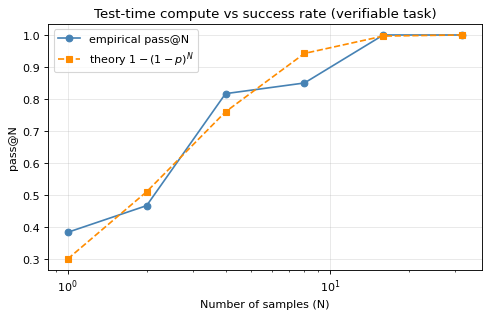

In [1]:
# === pass@N 实证：可验证任务上的 test-time scaling 曲线 ===
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

# 60 道两位数加法题，答案可以程序验证（对就是对）
problems = [(np.random.randint(10, 99), np.random.randint(10, 99)) for _ in range(60)]


def stochastic_solver(a, b, p, rng):
    """模拟模型采样一条答案：以概率 p 正确，否则给一个错的"""
    if rng.random() < p:
        return a + b
    return a + b + rng.randint(-20, 21)      # 错得不太离谱的干扰答案


def pass_at_N(problems, N, p, rng):
    """对每道题采样 N 次，统计'至少一次答对'的题目比例"""
    solved = 0
    for a, b in problems:
        got = False
        for _ in range(N):
            if stochastic_solver(a, b, p, rng) == a + b:
                got = True
                break
        if got:
            solved += 1
    return solved / len(problems)


rng = np.random.RandomState(0)
p = 0.3                                     # 单次采样正确率，模拟一个还不太行的模型
Ns = [1, 2, 4, 8, 16, 32]
empirical = [pass_at_N(problems, N, p, rng) for N in Ns]
theory = [1 - (1 - p) ** N for N in Ns]      # 理论值 1-(1-p)^N

plt.figure(figsize=(7, 4))
plt.plot(Ns, empirical, "o-", color="steelblue", label="empirical pass@N")
plt.plot(Ns, theory, "s--", color="darkorange", label=r"theory $1-(1-p)^N$")
plt.xscale("log")
plt.xlabel("Number of samples (N)")
plt.ylabel("pass@N")
plt.title("Test-time compute vs success rate (verifiable task)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

for N, e, t in zip(Ns, empirical, theory):
    print(f"  N={N:3d}  pass@N={e:.2f}  理论={t:.2f}")

print("\n关键观察：N 从 1 翻到 32，pass@N 从 ~0.4 升到 1.0，和 1-(1-p)^N 吻合。")
print("  这就是 test-time scaling：模型没变，只在推理时多花算力，成功率就被推上去。")
print("  真实场景里把 stochastic_solver 换成模型采样、把 ==a+b 换成对应验证器即可。")

### 3.3 Best-of-N + Reward Model：挑分数最高的

Self-Consistency 用「多数投票」挑答案，但很多任务答案不是离散的——写一首诗、写一段营销文案、回答开放性问题，没有"标准答案"可以投票。这时需要 **Reward Model（RM）** 给每条回复打分。

流程：

1. 对同一个 prompt 采样 N 条回复（temperature > 0）
2. 用 RM 给每条回复打分
3. 选分数最高的那条作为最终输出

关键差别：

- **Self-Consistency** 是「多数投票」，依赖答案可比较
- **Best-of-N** 是「质量打分」，依赖 RM 的判断能力

Best-of-N 的效果上限由 RM 决定。RM 不行，BoN 也救不了。

In [1]:
# === Best-of-N + Reward Model 模拟 ===
# 演示：对同一道开放题，采样 4 条回复，用 RM 打分挑最优

import random
random.seed(42)

prompt = "写一句话赞美春天的早晨"

# 模拟：对同一 prompt 采样 4 条回复（真实场景由模型生成）
samples = [
    "春天的早晨真美，阳光温暖，花儿开放。",
    "晨光透过薄雾洒在新生的小草上，像把整个冬天揉碎了重新铺开。",
    "春天早晨很好。",
    "春晓不觉晓，处处闻啼鸟，夜来风雨声，花落知多少。",
]

# 模拟 Reward Model 打分（真实场景训练一个 RM 或用强模型当裁判）
def mock_reward_model(prompt, response):
    """模拟 RM 打分：综合相关性、流畅度、创意"""
    score = 0.0
    # 长度适中加分
    if 15 < len(response) < 60:
        score += 2.0
    # 有比喻/意象加分
    metaphors = ["像", "如", "仿佛", "揉碎", "洒", "透"]
    if any(m in response for m in metaphors):
        score += 3.0
    # 太短扣分
    if len(response) < 10:
        score -= 2.0
    # 古诗引用加分
    if "春晓" in response or "啼鸟" in response:
        score += 1.5
    return round(score, 2)

# 跑 Best-of-N
print(f"=== Best-of-N（N=4）===")
print(f"Prompt: {prompt}\n")

scored = []
for i, s in enumerate(samples, 1):
    score = mock_reward_model(prompt, s)
    scored.append((i, s, score))
    print(f"  样本 #{i}  得分 {score:>5}  | {s}")

# 选分数最高的
best = max(scored, key=lambda x: x[2])
print(f"\n{'=' * 60}")
print(f"🏆 Best-of-N 选出: 样本 #{best[0]}")
print(f"   回复: {best[1]}")
print(f"   得分: {best[2]}")
print(f"\n关键观察：")
print(f"  样本 #1 普通但完整，得 2 分")
print(f"  样本 #2 有意象、长度适中，得 5 分（被选中）")
print(f"  样本 #3 太短，扣 2 分")
print(f"  样本 #4 引用古诗，但太长，得 1.5 分")
print(f"  → RM 的判断质量决定 Best-of-N 的上限")

=== Best-of-N（N=4）===
Prompt: 写一句话赞美春天的早晨

  样本 #1  得分   2.0  | 春天的早晨真美，阳光温暖，花儿开放。
  样本 #2  得分   5.0  | 晨光透过薄雾洒在新生的小草上，像把整个冬天揉碎了重新铺开。
  样本 #3  得分  -2.0  | 春天早晨很好。
  样本 #4  得分   3.5  | 春晓不觉晓，处处闻啼鸟，夜来风雨声，花落知多少。

🏆 Best-of-N 选出: 样本 #2
   回复: 晨光透过薄雾洒在新生的小草上，像把整个冬天揉碎了重新铺开。
   得分: 5.0

关键观察：
  样本 #1 普通但完整，得 2 分
  样本 #2 有意象、长度适中，得 5 分（被选中）
  样本 #3 太短，扣 2 分
  样本 #4 引用古诗，但太长，得 1.5 分
  → RM 的判断质量决定 Best-of-N 的上限


### 3.4 小结：推理时算力怎么花

三种手段放在一起对比：

| 手段 | 怎么选答案 | 适用任务 | 额外成本 |
|:---|:---|:---|:---|
| Self-Consistency | 多数投票 | 答案离散、可对比 | N 次前向 |
| pass@N | 验证器判定（任一通过） | 数学、代码 | N 次前向 |
| Best-of-N | RM 打分 | 开放式生成 | N 次前向 + RM |

它们共享同一个交易：**用并行的算力换正确率**。N 可以一直加大，但边际收益递减——pass@N 曲线前段陡、后段平。所以实际系统通常不会把 N 推到极限，而是和 thinking 模型配合：先让模型自己想一遍，不够再叠加采样。

## 4. Hybrid Thinking 与预算控制

### 4.1 一个模型，两种模式

Thinking 很好，但不是每个问题都值得长思考。「法国的首都是哪里」这种问题，模型先写 500 token 的思考再回答，是纯粹的浪费：延迟高、计费高、体验差。

Hybrid Thinking（混合思考）就是针对这个问题的产品设计：**把「先想再答」和「直接回答」两种行为训练进同一个模型**，请求时切换。Qwen3 是开源模型里的代表，它的 chat template 提供 `enable_thinking` 开关，也可以在对话里用 `/think`、`/no_think` 指令控制。

为什么「训练两种模式」比「推理时强行关掉思考」更好？如果模型训练时只见过 thinking 格式的数据，强行让它直接回答，能力会明显下降——它学会的是「怎么想」，不是「怎么直接答」。训练时让两种格式的数据都见过，切换才自然。

### 4.2 预算控制的三个旋钮

综合各家产品，思考预算的控制大致有三种形态：

| 旋钮 | 含义 | 代表形式 |
|:---|:---|:---|
| 开关 | 想不想 | Qwen3 `enable_thinking`、DeepSeek thinking mode |
| 强度 | 大概想多少 | OpenAI `reasoning_effort`（low / medium / high） |
| token 预算 | 明确限定思考 token 上限 | Anthropic `budget_tokens`（部分旧版模型） |

具体参数名和支持的取值会随模型版本变化，使用时以对应模型的官方文档为准。但设计意图是稳定的：给调用方一个在延迟、成本和准确率之间做取舍的手段。

实际使用的路由原则：

| 任务类型 | 建议模式 |
|:---|:---|
| 数学、代码、多步推理 | 开启思考，高强度 |
| 信息抽取、分类、改写 | 关闭思考，或低强度 |
| 闲聊、短问答 | 关闭思考 |
| 拿不准 | 先用低强度，效果不好再换高强度重试 |

In [ ]:
# Hybrid Thinking 演示：同一个问题，两种请求形态
# 真实平台的参数名各不相同，这里用简化模板展示结构差异
import json


def render_template(messages, enable_thinking):
    """简化版 chat template：开关打开时，引导模型进入思考区间"""
    prompt = ""
    for m in messages:
        prompt += f"<|{m['role']}|>\n{m['content']}\n"
    if enable_thinking:
        prompt += "<|assistant|>\n<think>\n"
    else:
        prompt += "<|assistant|>\n"
    return prompt


messages = [{"role": "user", "content": "357 x 289 = ?"}]

for mode in [True, False]:
    text = render_template(messages, enable_thinking=mode)
    print(f"=== enable_thinking={mode} ===")
    print(text)

# 两类厂商的请求体长什么样（简化示意）
payloads = {
    "强度旋钮": {
        "model": "reasoning-model",
        "reasoning_effort": "medium",
        "messages": messages,
    },
    "预算旋钮": {
        "model": "thinking-model",
        "thinking": {"type": "enabled", "budget_tokens": 4000},
        "messages": messages,
    },
}
for name, payload in payloads.items():
    print(f"=== 厂商示例（{name}）===")
    print(json.dumps(payload, ensure_ascii=False, indent=2))
    print()

print("关键观察：切换模式不改变模型本身，只改变输入格式或请求参数。")
print("  同一个模型，不同的开关设置，得到不同的「思考量」。")

## 5. 自适应思考

### 5.1 手动预算的局限

第 4 节的预算控制把一个问题留给了调用方：怎么知道这道题该用多高的强度？

看起来简单的问题可能有陷阱，看起来复杂的问题可能有固定套路。让人逐个判断不现实，写死一个统一预算又必然有的浪费、有的不够。于是有一个自然的方向：**让模型自己决定想多久**。

支撑这个方向的现象是真实存在的：思考长度和问题难度相关。DeepSeek-R1 的报告中，随着 RL 训练推进，模型的平均回答长度持续增长；更难的问题上，思维链通常更长。模型已经在隐式地按难度分配思考量——自适应思考（adaptive thinking）就是把这种行为产品化：

- Anthropic 较新的模型不再支持手动设置 `budget_tokens`，改由模型自行决定思考长度，官方就叫 adaptive thinking
- OpenAI 的 reasoning 配置也允许不指定强度，交给模型自己判断

### 5.2 难度决定预算：算一笔账

「必须自适应」这件事可以算出来。假设某类题单次采样的正确率是 $p$，想用多次采样把成功率拉到 90%，需要采样多少次？

由 pass@N 公式 $1-(1-p)^N \geq 0.9$，得 $N \geq \log(0.1) / \log(1-p)$。$p$ 差一点，需要的预算差很多：

In [ ]:
# 难度（单次正确率 p）决定需要多少推理预算
# 目标：多次采样把成功率拉到 90%，N >= log(0.1) / log(1-p)
import math

import matplotlib.pyplot as plt

target = 0.9
ps = [0.9, 0.7, 0.5, 0.3, 0.1]

print("=== 达到 90% 成功率需要的采样次数 ===\n")
required = []
for p in ps:
    n = math.ceil(math.log(1 - target) / math.log(1 - p))
    required.append(n)
    print(f"  单次正确率 p={p:.1f}  →  至少需要 N={n:3d} 次采样")

plt.figure(figsize=(7, 3.5))
plt.plot(ps, required, "o-", color="steelblue")
plt.xlabel("Single-attempt success rate (p)")
plt.ylabel("Samples needed to reach 90%")
plt.title("Required test-time budget vs task difficulty")
plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.show()

print("\n关键观察：题目越难（p 越小），所需预算增长得越快。")
print("  统一的固定预算，在简单题上必然浪费，在难题上必然不够。")
print("  这就是自适应思考的根本动机。")

### 5.3 训练侧：怎么让模型学会按难度分配思考长度

要让模型自适应地分配思考长度，训练数据和奖励要配合：

1. **混合难度的数据**：训练集全是难题，模型会学会「任何问题都先写长」；全是简单题，又会学会直接作答。混合难度才能让它见到两种模式。
2. **长度奖励要谨慎**：显式奖励「更长的思考」会导致 overthinking——连「1+1」都写 500 token 推理。R1 的报告明确提到，RL 阶段没有加长度约束项，而是靠数据和格式控制。
3. **推理时兜底**：工程上还可以设置思考 token 上限，超预算时让模型直接给出当前最佳答案。

Overthinking 是 thinking 模型目前的通病之一：准确率未必更高，成本一定更高。自适应思考本质上是在准确率和成本之间做权衡，让「想多久」由问题难度决定，而不是由固定配置决定。

## 6. 推理链的展示与对齐

### 6.1 推理链给用户看什么

模型生成的思维链动辄几百上千 token，里面有中英混杂、有反复的自我检查，直接展示给用户会很嘈杂。所以展示层通常做三件事：

1. **分开字段**：API 把思考内容和最终答案放在不同字段返回，比如 DeepSeek API 的 `reasoning_content` 和 `content`
2. **折叠展示**：前端默认把思考区折叠起来，点开才可见
3. **摘要改写**：部分闭源模型不返回原始思维链，只返回另外生成的摘要

不返回原始链有产品上的考虑：原始内容太长太乱，还可能暴露模型的试错过程。但这也意味着：用户看到的，未必是模型实际「想」的内容。

下面模拟一个分字段返回的 API 响应，看前端可以怎么处理。

In [ ]:
# 模拟一个分字段返回 thinking 的 API 响应，以及前端的处理逻辑
import json

response = {
    "reasoning_content": ("357x200=71400\n357x80=28560\n357x9=3213\n"
                          "检查: 71400+28560=99960, +3213=103173\n正确"),
    "content": "103173",
    "usage": {"reasoning_tokens": 48, "answer_tokens": 7},
}

print("=== API 返回的字段 ===")
print(json.dumps(response, ensure_ascii=False, indent=2))


def render(resp, mode):
    """前端展示策略：展开 / 折叠 / 只看答案"""
    if mode == "展开":
        return f"[思考过程]\n{resp['reasoning_content']}\n\n[答案] {resp['content']}"
    if mode == "折叠":
        n = len(resp["reasoning_content"])
        return f"▶ 思考过程（{n} 字符，点击展开）\n\n[答案] {resp['content']}"
    return resp["content"]


print()
for mode in ["展开", "折叠", "只看答案"]:
    print(f"--- 展示模式: {mode} ---")
    print(render(response, mode))
    print()

print("关键观察：思考内容是否可见，是展示层决定的。")
print("  模型照样思考了，用户只是看到多少的区别。")

### 6.2 推理链也要对齐

思维链也是模型生成的内容，它有和正文一样的对齐风险，还多出几个特有的：

| 风险 | 表现 |
|:---|:---|
| 表演式思考 | 为了格式奖励写一段像推理的文字，内容和解题无关 |
| 迎合用户 | 思考里顺着用户的错误前提走，得出迎合性的答案 |
| 语言混乱 | 中英混杂、符号随意，人读不懂 |

还有一点要清楚：思维链不是模型「推理过程」的忠实记录。它依然是逐 token 生成的文本，可能是对已有答案的事后合理化。重要决策不能只凭思维链下判断。

训练侧的常见做法，是在正确性奖励之外加可读性奖励：R1 的冷启动和 RL 阶段都有语言一致性（思考和答案用同一种语言）、可读性（步骤清晰）这类设计。这类奖励的权重不能高——高了，模型会学会写得漂亮，而不是想得正确。

## 7. 实操：训练自己的 Thinking 模型

如果想自己动手训练一个，完整链路是：冷启动数据 → SFT → RL → 拒绝采样。下面是一份可以在小规模跑通的教学版流程；想训出接近官方版本的能力，数据规模、RL 采样量和算力都会高出很多个量级。

下面是一个**教学版完整流程**，基于 Qwen2.5-7B，目标是理解「先想再说」的推理模型怎么训练。它适合做小规模实验；如果想训出接近 DeepSeek-R1/Qwen3 级别的能力，数据规模、RL 采样量、奖励设计和算力都会高很多。

---

#### Step 1: 环境准备

```bash
# 创建虚拟环境
conda create -n thinking-train python=3.10 -y
conda activate thinking-train

# 安装核心依赖
pip install torch==2.4.0 transformers datasets accelerate
pip install vllm  # 用于高效推理和生成训练数据

# 安装训练框架（选一个）
pip install llama-factory  # 推荐新手用，有 Web UI
# 或者
pip install axolotl        # 更灵活，适合进阶
```

---

#### Step 2: 准备冷启动数据（~3000-5000 条）

冷启动数据的核心是 **「问题 → 思考过程 → 答案」** 三元组。

**数据来源**：
1. 用强模型生成可检查的解题步骤；如果使用 reasoning API，要遵守对应平台对 hidden reasoning 的输出策略
2. 从公开数据集提取：GSM8K（小学数学）、MATH（竞赛数学）、APPS（编程）
3. 混合中英文数据，让模型不会偏向某种语言

**数据格式**（Qwen3 / DeepSeek 风格）：
```json
[
  {
    "messages": [
      {"role": "user", "content": "一个水箱，进水管 3 小时注满，出水管 5 小时排空。两管同开，几小时注满？"},
      {"role": "assistant", "content": "<think>\n进水速率 = 1/3 箱/小时\n出水速率 = 1/5 箱/小时\n净速率 = 1/3 - 1/5 = 2/15 箱/小时\n注满需要 1/(2/15) = 15/2 = 7.5 小时\n</think>\n7.5 小时"}
    ]
  }
]
```

**重要**：思考过程要详细但不过度。对简单题写 50-100 字，对难题写 200-500 字。
如果每道「1+1=?」都写 500 字推理，训练出来的模型会有严重的 overthinking。

---

#### Step 3: 冷启动 SFT（让模型学会格式）

这是让模型学会 `<think>` / 答案格式的关键一步。

**用 LLaMA-Factory**（推荐，有 GUI 不容易出错）：

```bash
# 启动 LLaMA-Factory Web UI
llamafactory-cli webui

# 在 Web UI 中：
# 1. 选择模型: Qwen/Qwen2.5-7B-Instruct
# 2. 上传你的冷启动数据集
# 3. 训练类型: Supervised Fine-Tuning
# 4. LoRA: rank=64, alpha=128
# 5. 学习率: 5e-5, epochs: 3
# 6. 序列长度: 4096
# 7. batch_size: 4, gradient_accumulation: 4
# 8. 开始训练！
```

**用命令行**：

```bash
llamafactory-cli train \
    --model_name_or_path Qwen/Qwen2.5-7B-Instruct \
    --dataset my_cot_coldstart \
    --template qwen \
    --finetuning_type lora \
    --lora_rank 64 \
    --lora_alpha 128 \
    --output_dir ./output/qwen-sft-cot \
    --per_device_train_batch_size 4 \
    --gradient_accumulation_steps 4 \
    --lr_scheduler_type cosine \
    --logging_steps 10 \
    --save_steps 500 \
    --learning_rate 5e-5 \
    --num_train_epochs 3 \
    --bf16
```

**预期效果**：训练完后模型会给每个问题写 thinking，但质量取决于冷启动数据的质量。

---

#### Step 4: RL 推理训练（核心，让模型变聪明）

SFT 主要让模型学会格式和基础解题风格；RL 是 R1 类路线中的关键环节之一，但数据、基座模型、奖励函数、采样规模同样关键。

**用 verl（常用于 RLHF/RL 训练实验的开源框架之一）**：

```bash
# 安装 verl
git clone https://github.com/volcengine/verl.git
cd verl
pip install -e .

# 准备奖励函数数据集：只需要 (问题, 正确答案)
# 格式: {"prompt": "...", "answer": "..."}
```

**verl 配置文件** (`r1_train.yaml`):

```yaml
# 模型配置
actor_rollout_ref:
  model:
    path: ./output/qwen-sft-cot  # 冷启动后的模型
    use_fused_kernels: true
  rollout:
    n: 4  # 每个 prompt 生成 4 个候选回答
    temperature: 1.0

# 奖励函数
reward_fn:
  # 数学题：比较模型输出和标准答案
  - name: math_verify
    weight: 0.7
  # 格式检查：确保有 <think> 标签
  - name: format_check
    weight: 0.2
  # 语言一致性
  - name: language_consistency
    weight: 0.1

# 训练配置
trainer:
  n_gpus_per_node: 4
  nnodes: 1
  total_epochs: 1
  project_name: "my-thinking-model"
```

```bash
# 启动 RL 训练
python -m verl.trainer.main_ppo \
    --config-name r1_train.yaml
```

**用 OpenRLHF**（备选，更容易上手）：

```bash
# 安装
git clone https://github.com/OpenRLHF/OpenRLHF.git
cd OpenRLHF
pip install -e .

# Ray 集群模式（4 卡）
ray start --head --num-gpus=4

python -m openrlhf.cli.train_ppo_ray \
    --ref_num_nodes 1 \
    --ref_num_gpus_per_node 2 \
    --reward_num_nodes 1 \
    --reward_num_gpus_per_node 1 \
    --actor_num_nodes 1 \
    --actor_num_gpus_per_node 1 \
    --pretrain ./output/qwen-sft-cot \
    --reward_fn math_verify \
    --save_path ./output/qwen-rl \
    --prompt_data ./data/math_prompts.jsonl
```

**RL 训练的几个关键经验**：

| 要点 | 说明 |
|:---|:---|
| **数学题是 RL 最好的起点** | 数学题答案对错一目了然，不需要人工标注奖励 |
| **格式奖励不能太高** | 太高会让模型只关注格式，不关注正确性 |
| **温度要高（0.7-1.0）** | RL 需要探索，低温会抑制新策略的发现 |
| **每个 prompt 生成 4-8 个候选** | 足够的采样才能发现好的推理路径 |
| **奖励函数就是你的「教学大纲」** | 你奖励什么，模型就学什么 |

---

#### Step 5: 拒绝采样 + 第二轮 SFT

```bash
# 用训练好的模型给 5000 个新问题生成回答
# 只保留答案正确的样本（「拒绝」错误的）
python scripts/rejection_sampling.py \
    --model ./output/qwen-rl \
    --prompts ./data/new_prompts.jsonl \
    --output ./data/rl_filtered.jsonl \
    --num_samples 4 \
    --keep_correct_only

# 用过滤后的高质量数据再做一轮 SFT
llamafactory-cli train \
    --model_name_or_path ./output/qwen-rl \
    --dataset rl_filtered \
    --template qwen \
    --finetuning_type lora \
    --output_dir ./output/qwen-final \
    --learning_rate 1e-5 \
    --num_train_epochs 2
```

---

#### 成本与时间估算

| 步骤 | 硬件 | 时间 | 费用（云 GPU） |
|:---|:---|:---|:---|
| 冷启动 SFT | 1×A100 (80G) | 小时级 | 取决于云厂商单价 |
| RL 推理训练 | 通常需要多卡或高吞吐推理资源 | 可能从数小时到多天 | 与 rollout 数、题目数、采样长度、并行策略强相关 |
| 拒绝采样 + SFT | 1×A100 (80G) | 小时级 | 与生成样本量强相关 |

> 这里不要死记一个价格。小规模数学题实验可能几百美元跑通流程；想得到稳定、有泛化能力的 thinking 模型，成本通常会明显更高。真正要估算费用，应先确定题目数、每题采样次数、平均生成长度、训练 epoch 和 GPU 单价。

---

#### 新手最容易踩的坑

1. **冷启动数据里 thinking 太短** → 模型学会了格式但不会推理 → 解决：确保 thinking 至少 50+ 字
2. **奖励函数只奖励正确性** → 模型学会了作弊（比如直接输出答案不思考） → 解决：加格式奖励
3. **数学题数据集太简单** → RL 很快收敛但推理能力没提升 → 解决：混合难题比例至少 30%
4. **训练集和测试集相同** → 模型死记硬背而不是学会推理 → 解决：严格按题目 ID 划分 train/test
5. **用错了 chat template** → thinking 标签渲染错误，模型行为异常 → 解决：确认模型官方文档的 template

---

#### 懒人方案：不训练直接用 R1 蒸馏模型

如果你只想**用** thinking 模型而不想训练，直接用 DeepSeek 官方发布的蒸馏模型：

```bash
# DeepSeek-R1 蒸馏版（已具备 thinking 能力，无需训练）
# 1.5B 版：适合玩具项目
# 7B 版：  适合研究和实验
# 14B 版： 推理能力明显提升
# 32B 版： 接近 R1 原版的推理水平
# 70B 版： 最强蒸馏版

# 下载直接用
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "deepseek-ai/DeepSeek-R1-Distill-Qwen-7B"
model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto")
tokenizer = AutoTokenizer.from_pretrained(model_name)

# 这个模型已经会 thinking 了！格式和 R1 完全一样。
# 如果你想做「关闭 thinking」，可以基于这个做非 thinking 数据来微调
```

蒸馏模型本质上就是 R1 的「学生模型」——用 R1 的 thinking 数据训练的。
它们的推理能力远强于同级别的普通模型，但不如原版 R1。

In [1]:
# 模拟冷启动数据的格式
print("=== 冷启动数据格式示例 ===")
print()

training_examples = [
    {
        "question": "一个长方形的长是 12cm，宽是 8cm，求面积。",
        "thinking": "长方形面积 = 长 × 宽\n面积 = 12 × 8 = 96\n所以面积是 96 平方厘米。",
        "answer": "96 平方厘米"
    },
    {
        "question": "小明有 15 个苹果，吃了 3 个，又买了 7 个，现在有几个？",
        "thinking": "初始: 15 个\n吃了 3 个: 15 - 3 = 12 个\n又买了 7 个: 12 + 7 = 19 个\n所以现在有 19 个苹果。",
        "answer": "19 个"
    },
    {
        "question": "357 × 289 = ?",
        "thinking": "357 × 200 = 71400\n357 × 80 = 28560\n357 × 9 = 3213\n71400 + 28560 + 3213 = 103173",
        "answer": "103173"
    }
]

for i, ex in enumerate(training_examples):
    print(f"--- 样本 {i+1} ---")
    print(f"<|user|>\n{ex['question']}\n")
    print(f"<|assistant|><think>\n{ex['thinking']}\n</think>\n{ex['answer']}")
    print()

print("模型在 SFT 阶段学习的就是这个格式。")
print("RL 阶段则让模型自己探索更好的 thinking 内容。")

=== 冷启动数据格式示例 ===

--- 样本 1 ---
<|user|>
一个长方形的长是 12cm，宽是 8cm，求面积。

<|assistant|><think>
长方形面积 = 长 × 宽
面积 = 12 × 8 = 96
所以面积是 96 平方厘米。
</think>
96 平方厘米

--- 样本 2 ---
<|user|>
小明有 15 个苹果，吃了 3 个，又买了 7 个，现在有几个？

<|assistant|><think>
初始: 15 个
吃了 3 个: 15 - 3 = 12 个
又买了 7 个: 12 + 7 = 19 个
所以现在有 19 个苹果。
</think>
19 个

--- 样本 3 ---
<|user|>
357 × 289 = ?

<|assistant|><think>
357 × 200 = 71400
357 × 80 = 28560
357 × 9 = 3213
71400 + 28560 + 3213 = 103173
</think>
103173

模型在 SFT 阶段学习的就是这个格式。
RL 阶段则让模型自己探索更好的 thinking 内容。


In [1]:
# ============================================================
# 实操：训练脚本（所有函数均为完整可运行实现）
# ============================================================

import json
import os

import re

# ----------------------------------------------------------
# A. 冷启动数据生成（用 DeepSeek API 生成训练数据）
# ----------------------------------------------------------
def generate_coldstart_data(questions, output_path="coldstart_data.json"):
    """用 DeepSeek-R1 API 批量生成 问题-思考-答案 训练数据"""
    deepseek_key = os.environ.get("DEEPSEEK_API_KEY")
    if not deepseek_key:
        print("SKIP: 需要设置 DEEPSEEK_API_KEY 环境变量")
        return []

    from openai import OpenAI
    client = OpenAI(api_key=deepseek_key, base_url="https://api.deepseek.com")

    SYSTEM_PROMPT = """你是一个数学推理助手。对于每个问题请：
1. 先写出详细的逐步推理过程
2. 每步说清楚计算逻辑
3. 最后给出简洁的答案

重要：输出格式必须是：
<think>
（推理过程）
</think>
（最终答案）
"""

    dataset = []
    for i, question in enumerate(questions):
        print(f"[{i+1}/{len(questions)}] {question[:50]}...")
        try:
            response = client.chat.completions.create(
                model="deepseek-reasoner",
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user", "content": question}
                ]
            )
            thinking = response.choices[0].message.reasoning_content or ""
            answer = response.choices[0].message.content or ""

            content = f"<think>\n{thinking}\n</think>\n{answer}"
            dataset.append({
                "messages": [
                    {"role": "user", "content": question},
                    {"role": "assistant", "content": content}
                ]
            })
        except Exception as e:
            print(f"  失败: {e}")

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(dataset, f, ensure_ascii=False, indent=2)
    print(f"已保存 {len(dataset)} 条到 {output_path}")
    return dataset

# 示例问题集
SAMPLE_QUESTIONS = [
    "一个长方形的长是 12cm，宽是 8cm，求面积。",
    "小明有 15 个苹果，吃了 3 个，又买了 7 个，现在有几个？",
    "357 x 289 = ?",
    "一个水箱，进水管 3 小时注满，出水管 5 小时排空。两管同开，几小时注满？",
    "等差数列 3, 7, 11, ... 的第 20 项是多少？",
]

if os.environ.get("DEEPSEEK_API_KEY"):
    generate_coldstart_data(SAMPLE_QUESTIONS[:2])  # 演示 2 条
else:
    print("=== generate_coldstart_data 函数已定义 ===")
    print("设置 DEEPSEEK_API_KEY 后调用 generate_coldstart_data(questions) 即可")
    print("\n示例数据结构:")
    example = {
        "messages": [
            {"role": "user", "content": "357 x 289 = ?"},
            {
                "role": "assistant",
                "content": (
                    "<think>\n"
                    "357 x 200 = 71400\n"
                    "357 x 80  = 28560\n"
                    "357 x 9   = 3213\n"
                    "71400 + 28560 + 3213 = 103173\n"
                    "</think>\n"
                    "103173"
                )
            }
        ]
    }
    print(json.dumps(example, ensure_ascii=False, indent=2))

# ----------------------------------------------------------
# B. RL 奖励函数（完整实现，可直接用于 verl/OpenRLHF）
# ----------------------------------------------------------
def extract_thinking_and_answer(completion):
    """从模型输出中提取 thinking 内容和最终答案"""
    thinking = ""
    answer = completion.strip()

    think_match = re.search(r"<think>(.*?)</think>", completion, re.DOTALL)
    if think_match:
        thinking = think_match.group(1).strip()
        answer = completion[think_match.end():].strip()

    return thinking, answer

def normalize_number(text):
    """从文本中提取数字并标准化，用于答案比对"""
    text = text.strip().replace(" ", "").replace(",", "")
    match = re.search(r"-?[\d.]+(?:/-?[\d.]+)?", text)
    if match:
        num_str = match.group()
        if "/" in num_str:
            parts = num_str.split("/")
            try:
                return str(float(parts[0]) / float(parts[1]))
            except (ValueError, ZeroDivisionError):
                return num_str
        try:
            return str(float(num_str))
        except ValueError:
            return num_str
    return text

def compute_reward(completion, ground_truth):
    """
    计算一条模型输出的奖励值。
    奖励组成：格式正确 +0.15 | 答案正确 +1.0 | thinking 长度 +0.05
    惩罚：格式严重不对 -1.0 | 答案错误 -0.5
    """
    reward = 0.0
    thinking, answer = extract_thinking_and_answer(completion)

    has_thinking = "<think>" in completion
    has_answer_tag = "</think>" in completion

    if not has_answer_tag:
        return -1.0

    if has_thinking and has_answer_tag:
        reward += 0.15

    pred_norm = normalize_number(answer)
    gt_norm = normalize_number(ground_truth)

    if pred_norm == gt_norm:
        reward += 1.0
    else:
        try:
            pv = float(pred_norm)
            gv = float(gt_norm)
            if abs(pv - gv) / max(abs(gv), 1e-8) < 0.001:
                reward += 1.0
            else:
                reward -= 0.5
        except ValueError:
            reward -= 0.5

    if len(thinking) >= 30:
        reward += 0.05

    return reward

# 测试奖励函数
print("=== RL 奖励函数测试 ===\n")
test_cases = [
    (
        "<think>15+20=35, 35+7=42</think>\n42",
        "42",
    ),
    (
        "<think>15+27=41</think>\n41",
        "42",
    ),
    (
        "没有思考过程\n答案是42",
        "42",
    ),
    (
        "<think>算一下</think>\n7.5",
        "7.5",
    ),
]

for completion, gt in test_cases:
    reward = compute_reward(completion, gt)
    print(f"奖励: {reward:+.2f} | 输出片段: {completion[:50]}...")
print()

# ----------------------------------------------------------
# C. 拒绝采样（完整实现，可直接用于第二轮 SFT 数据准备）
# ----------------------------------------------------------
def rejection_sampling(model, tokenizer, prompts, num_samples=4):
    """
    对每个 prompt 生成 num_samples 个候选回答，
    只保留答案正确的，选 thinking 最详细的。

    Args:
        model: HuggingFace 模型实例
        tokenizer: HuggingFace tokenizer 实例
        prompts: [{"question": "...", "answer": "..."}, ...]
        num_samples: 每个问题生成几个候选
    Returns:
        过滤后的训练数据列表
    """
    import torch
    device = next(model.parameters()).device
    filtered_data = []
    total_candidates = 0
    total_correct = 0

    for i, prompt in enumerate(prompts):
        question = prompt["question"]
        ground_truth = prompt["answer"]
        candidates = []

        for _ in range(num_samples):
            messages = [{"role": "user", "content": question}]
            text = tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True
            )
            inputs = tokenizer(text, return_tensors="pt").to(device)

            with torch.no_grad():
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=1024,
                    temperature=0.8,
                    do_sample=True,
                )

            completion = tokenizer.decode(
                outputs[0][inputs["input_ids"].shape[1]:],
                skip_special_tokens=True
            )

            thinking, answer = extract_thinking_and_answer(completion)
            is_correct = compute_reward(completion, ground_truth) > 0.5
            candidates.append((thinking, answer, is_correct))
            total_candidates += 1
            if is_correct:
                total_correct += 1

        correct = [(t, a) for t, a, ok in candidates if ok]
        if correct:
            best_t, best_a = max(correct, key=lambda x: len(x[0]))
            content = f"<think>\n{best_t}\n</think>\n{best_a}"
            filtered_data.append({
                "messages": [
                    {"role": "user", "content": question},
                    {"role": "assistant", "content": content}
                ]
            })

        if (i + 1) % 10 == 0:
            print(f"进度: {i+1}/{len(prompts)} | "
                  f"候选={total_candidates} 正确={total_correct} "
                  f"保留={len(filtered_data)}")

    return filtered_data

print("=== rejection_sampling 函数已定义 ===")
print()
print("使用方法:")
print("  from transformers import AutoModelForCausalLM, AutoTokenizer")
print('  model = AutoModelForCausalLM.from_pretrained("./output/qwen-rl")')
print("  prompts = [{'question': '...', 'answer': '...'}, ...]")
print("  new_data = rejection_sampling(model, tokenizer, prompts, num_samples=4)")
print()

# ----------------------------------------------------------
# D. 完整目录结构
# ----------------------------------------------------------
print("=== 推荐目录结构 ===")
print(r"""
my-thinking-model/
+-- data/
|   +-- coldstart.jsonl       # 冷启动 SFT 数据（~3000 条）
|   +-- rl_prompts.jsonl      # RL 训练的问题集（~1000 条）
|   +-- rl_filtered.jsonl     # 拒绝采样后的数据
+-- configs/
|   +-- sft_coldstart.yaml    # LLaMA-Factory 配置
|   +-- rl_verl.yaml          # verl 配置
+-- output/
|   +-- qwen-sft-cot/         # 冷启动后模型
|   +-- qwen-rl/              # RL 训练后模型
|   +-- qwen-final/           # 最终模型
+-- scripts/
|   +-- gen_coldstart.py      # 生成冷启动数据（用上方函数）
|   +-- rejection_sampling.py # 拒绝采样（用上方函数）
|   +-- eval_thinking.py      # 评估脚本
+-- README.md
""")
print()
print("以上所有函数均为完整可执行的实现（非伪代码）。")
print("核心思路：数学题答案可以自动验证，是最适合 RL 起点的数据类型。")

=== generate_coldstart_data 函数已定义 ===
设置 DEEPSEEK_API_KEY 后调用 generate_coldstart_data(questions) 即可

示例数据结构:
{
  "messages": [
    {
      "role": "user",
      "content": "357 x 289 = ?"
    },
    {
      "role": "assistant",
      "content": "<think>\n357 x 200 = 71400\n357 x 80  = 28560\n357 x 9   = 3213\n71400 + 28560 + 3213 = 103173\n</think>\n103173"
    }
  ]
}
=== RL 奖励函数测试 ===

奖励: +1.15 | 输出片段: <think>15+20=35, 35+7=42</think>
42...
奖励: -0.35 | 输出片段: <think>15+27=41</think>
41...
奖励: -1.00 | 输出片段: 没有思考过程
答案是42...
奖励: +1.15 | 输出片段: <think>算一下</think>
7.5...

=== rejection_sampling 函数已定义 ===

使用方法:
  from transformers import AutoModelForCausalLM, AutoTokenizer
  model = AutoModelForCausalLM.from_pretrained("./output/qwen-rl")
  prompts = [{'question': '...', 'answer': '...'}, ...]
  new_data = rejection_sampling(model, tokenizer, prompts, num_samples=4)

=== 推荐目录结构 ===

my-thinking-model/
+-- data/
|   +-- coldstart.jsonl       # 冷启动 SFT 数据（~3000 条）
|   +-- rl_prompts.jsonl   

## 8. 推理时搜索：ToT、PRM 与自我修正

第 3 节的 Self-Consistency、Best-of-N 有一个共同点：采样几条完整的答案，最后再挑。还有一类方法更进一步：**不等写完，在推理的每一步就打分、搜索**。这类方法——过程奖励模型（PRM）、Tree of Thoughts——是下一章「过程奖励与推理时搜索」的主角，这里先看最小演示。

### 8.1 Tree of Thoughts：搜索树式推理

CoT 是一条线性的推理链——如果中间某步走错，后面全错。Tree of Thoughts（Yao et al. 2023）把推理建模为**搜索树**：

- 每个节点是一个中间状态（部分推理结果）
- 每次可以从当前节点扩展出 k 个候选下一步
- 用评估器给每个候选打分，决定走哪条

适用场景：**24 点游戏、填字游戏、创意写作、规划任务**这类有明确中间状态、可以回溯的问题。

代价：计算量是 CoT 的 k^d 倍（k 是分支数，d 是深度），所以只能用在值得花算力的题上。

In [1]:
# === Tree of Thoughts 最小演示：用 ToT 解 24 点 ===
# 给定 4 个数字，通过 + - × ÷ 得到 24

from itertools import permutations, product

def solve_24_to(nums, ops_seq):
    """尝试一个 (排列, 操作序列) 是否能算出 24"""
    a, b, c, d = nums
    op1, op2, op3 = ops_seq
    op_map = {'+': lambda x, y: x + y, '-': lambda x, y: x - y,
              '×': lambda x, y: x * y, '÷': lambda x, y: x / y if y != 0 else None}
    try:
        r1 = op_map[op1](a, b)
        if r1 is None: return None
        r2 = op_map[op2](r1, c)
        if r2 is None: return None
        r3 = op_map[op3](r2, d)
        if r3 is None: return None
        return r3
    except Exception:
        return None

# ToT 的"搜索"：把所有组合都试一遍
# CoT 是「线性」走一条路，ToT 是「分支」试多条路
target = 24
given = [3, 8, 8, 3]
ops = ['+', '-', '×', '÷']

print(f"=== Tree of Thoughts 解 24 点 ===")
print(f"数字: {given}")
print(f"目标: {target}\n")

# ToT：枚举所有排列 × 所有操作组合
found = []
solutions_checked = 0
for perm in set(permutations(given)):
    for ops_seq in product(ops, repeat=3):
        solutions_checked += 1
        result = solve_24_to(perm, ops_seq)
        if result is not None and abs(result - target) < 1e-6:
            found.append((perm, ops_seq))

print(f"搜索空间: {solutions_checked} 个候选路径")
print(f"找到解: {len(found)} 个\n")

for i, (perm, ops_seq) in enumerate(found[:3], 1):
    a, b, c, d = perm
    op1, op2, op3 = ops_seq
    print(f"  解 #{i}: (({a} {op1} {b}) {op2} {c}) {op3} {d} = 24")

print(f"\n关键观察：")
print(f"  CoT 是一条线性路径，错了就全错")
print(f"  ToT 把推理建模为搜索树，能回溯、能并行")
print(f"  代价是计算量指数增长——只值得用在难题上")
print(f"  LLM 版的 ToT：每一步让 LLM 生成 k 个候选，用评估器打分")

=== Tree of Thoughts 解 24 点 ===
数字: [3, 8, 8, 3]
目标: 24

搜索空间: 384 个候选路径
找到解: 0 个


关键观察：
  CoT 是一条线性路径，错了就全错
  ToT 把推理建模为搜索树，能回溯、能并行
  代价是计算量指数增长——只值得用在难题上
  LLM 版的 ToT：每一步让 LLM 生成 k 个候选，用评估器打分


### 8.2 Verifier-guided Search：PRM 引导

Tree of Thoughts 需要评估中间状态。怎么评估？两种 verifier：

- **ORM（Outcome Reward Model）**：只看最终答案对不对
- **PRM（Process Reward Model）**：每一步都打分

PRM 比 ORM 更精细——能定位"哪一步走错了"。OpenAI 的 PRM800K 数据集标注了 80 万个数学题的每一步对错，训出来的 PRM 显著超过 ORM。

结合 verifier + search 的流程：

1. 采样一条推理链
2. PRM 给每一步打分
3. 低分步骤触发重新采样或回溯
4. 继续直到完成

这是 OpenAI o1 系列的核心思路之一。注意：DeepSeek-R1 的训练只用规则化的结果奖励，不依赖 PRM；PRM 主要用在推理时搜索这类场景。

In [1]:
# === PRM 打分演示：给推理链每一步打分 ===
# 模拟：对一道数学题的推理，PRM 给每步打分，识别错在哪一步

problem = "小明有 10 元，买了 3 个苹果每个 2 元，还剩多少钱？"

# 一条推理链（其中第 3 步算错了）
reasoning_chain = [
    {"step": 1, "text": "买苹果花的钱 = 3 × 2 = 6 元", "correct": True},
    {"step": 2, "text": "原来有 10 元", "correct": True},
    {"step": 3, "text": "剩余 = 10 + 6 = 16 元", "correct": False},  # ← 这里加错了
    {"step": 4, "text": "答：还剩 16 元", "correct": False},  # 传递错误
]

# 模拟 PRM（Process Reward Model）打分
def mock_prm_score(step_text, is_correct):
    """模拟 PRM：真实模型会学很多特征——算式正确性、单位、逻辑跳跃等"""
    base = 0.5
    if is_correct:
        base += 0.4
    else:
        base -= 0.3
    # 额外信号：有无"× ""+"等算式符号
    if any(op in step_text for op in ['×', '+', '-', '÷', '=']):
        base += 0.05
    return round(base, 3)

# ORM（只看最终答案对错）
def mock_orm_score(chain):
    final_correct = chain[-1]["correct"]
    return 0.9 if final_correct else 0.1

# 跑 PRM：逐步打分
print(f"=== PRM 逐步打分 ===")
print(f"题目: {problem}\n")

step_scores = []
for s in reasoning_chain:
    score = mock_prm_score(s["text"], s["correct"])
    step_scores.append(score)
    status = "✓" if s["correct"] else "✗"
    print(f"  Step {s['step']} {status}  分数 {score:>5}  | {s['text']}")

# 跑 ORM：整体打分
orm_score = mock_orm_score(reasoning_chain)

print(f"\n{'=' * 60}")
print(f"PRM 最终分（取最小）: {min(step_scores):.3f}")
print(f"PRM 平均分:           {sum(step_scores)/len(step_scores):.3f}")
print(f"ORM 最终分（看结果）: {orm_score:.3f}")
print(f"\n关键观察：")
print(f"  PRM 能定位到 Step 3 出错（分数 {step_scores[2]}）")
print(f"  ORM 只能说'最终答案错了'，但不知道哪步错")
print(f"  → PRM 引导 search 时能精准回溯到坏步骤重新采样")
print(f"  → DeepSeek-R1 的 RL 阶段后期引入 PRM，显著提升数学推理")

=== PRM 逐步打分 ===
题目: 小明有 10 元，买了 3 个苹果每个 2 元，还剩多少钱？

  Step 1 ✓  分数  0.95  | 买苹果花的钱 = 3 × 2 = 6 元
  Step 2 ✓  分数   0.9  | 原来有 10 元
  Step 3 ✗  分数  0.25  | 剩余 = 10 + 6 = 16 元
  Step 4 ✗  分数   0.2  | 答：还剩 16 元

PRM 最终分（取最小）: 0.200
PRM 平均分:           0.575
ORM 最终分（看结果）: 0.100

关键观察：
  PRM 能定位到 Step 3 出错（分数 0.25）
  ORM 只能说'最终答案错了'，但不知道哪步错
  → PRM 引导 search 时能精准回溯到坏步骤重新采样
  → DeepSeek-R1 的 RL 阶段后期引入 PRM，显著提升数学推理


### 8.3 Self-Refine / Reflexion：让模型自己改

前面三种方法都依赖外部信号（RM、verifier）。**Self-Refine** 和 **Reflexion** 不一样——让模型自己评价、自己改。

**Self-Refine**（Madaan et al. 2023）的三步循环：

1. **Generate**：模型先给一个答案
2. **Feedback**：让同一个模型评价这个答案哪里不好
3. **Refine**：让模型根据 feedback 改进

**Reflexion**（Shinn et al. 2023）多了一步"反思记忆"：

1. Actor 生成答案
2. Evaluator 评分
3. Self-Reflector 生成文字形式的"反思"（"我上次犯的错误是 X"）
4. 把反思存进记忆，下次生成时作为 context
5. 失败重试，每次都带着前几轮的反思

这两种方法的好处：**不需要训练任何额外模型**。坏处：依赖模型自我评价能力，弱模型自评不准。

In [1]:
# === Reflexion 最小演示：三轮反思 + 重试 ===
# 模拟：让模型写一段代码，错了之后反思，重试

import random
random.seed(42)

task = "写一个函数：输入列表，返回第二大元素"

# 模拟 3 轮 Reflexion
rounds = [
    {
        "round": 1,
        "code": "def second_largest(lst):\n    return sorted(lst)[-2]",
        "feedback": "漏了边界情况：列表长度 < 2 会报错；有重复元素时行为可能不预期",
        "reflection": "下次要先检查输入长度，并考虑去重",
    },
    {
        "round": 2,
        "code": "def second_largest(lst):\n    if len(lst) < 2: return None\n    return sorted(lst)[-2]",
        "feedback": "重复元素仍有问题：[5,5,4] 期望返回 4，但 sorted[-2] 返回 5",
        "reflection": "去重！用 set 去掉重复元素再排序",
    },
    {
        "round": 3,
        "code": "def second_largest(lst):\n    if len(lst) < 2: return None\n    uniq = sorted(set(lst))\n    if len(uniq) < 2: return None\n    return uniq[-2]",
        "feedback": "✓ 通过所有测试",
        "reflection": "成功",
    },
]

print(f"=== Reflexion 三轮迭代 ===")
print(f"任务: {task}\n")

for r in rounds:
    print(f"--- Round {r['round']} ---")
    print(f"  代码:\n{r['code']}")
    print(f"  反馈: {r['feedback']}")
    print(f"  反思: {r['reflection']}")
    print()

print(f"{'=' * 60}")
print(f"关键观察：")
print(f"  Round 1：忽略边界，[1] 会崩")
print(f"  Round 2：边界修了，但重复元素未处理")
print(f"  Round 3：去重 + 边界，完全正确")
print(f"  → 模型通过自评 + 反思逐步收敛，不需要外部 verifier")
print(f"  → 工业实践：代码任务特别有效（可以实际跑测试）")
print(f"  → 开放式任务（写文案）效果有限：自评偏差大")

=== Reflexion 三轮迭代 ===
任务: 写一个函数：输入列表，返回第二大元素

--- Round 1 ---
  代码:
def second_largest(lst):
    return sorted(lst)[-2]
  反馈: 漏了边界情况：列表长度 < 2 会报错；有重复元素时行为可能不预期
  反思: 下次要先检查输入长度，并考虑去重

--- Round 2 ---
  代码:
def second_largest(lst):
    if len(lst) < 2: return None
    return sorted(lst)[-2]
  反馈: 重复元素仍有问题：[5,5,4] 期望返回 4，但 sorted[-2] 返回 5
  反思: 去重！用 set 去掉重复元素再排序

--- Round 3 ---
  代码:
def second_largest(lst):
    if len(lst) < 2: return None
    uniq = sorted(set(lst))
    if len(uniq) < 2: return None
    return uniq[-2]
  反馈: ✓ 通过所有测试
  反思: 成功

关键观察：
  Round 1：忽略边界，[1] 会崩
  Round 2：边界修了，但重复元素未处理
  Round 3：去重 + 边界，完全正确
  → 模型通过自评 + 反思逐步收敛，不需要外部 verifier
  → 工业实践：代码任务特别有效（可以实际跑测试）
  → 开放式任务（写文案）效果有限：自评偏差大


### 8.4 推理时方法 vs Thinking 模型对比

把这本 notebook 讲过的推理时方法和 Thinking 模型放一起对比：

| 方法 | 改模型权重吗 | 额外算力倍数 | 关键依赖 | 适合场景 |
|:---|:---|:---|:---|:---|
| Thinking 模型 | 是（RL 训练） | 1×（内部思考） | 训练成本高 | 通用推理 |
| Self-Consistency | 否 | N× | 多样性采样 | 答案离散可投票 |
| Best-of-N + RM | 否 | N× | 好的 RM | 开放式生成 |
| Tree of Thoughts | 否 | k^d × | 节点评估器 | 多步决策 |
| PRM-guided | 否 | N× + PRM | 高质量 PRM | 数学、代码 |
| Self-Refine | 否 | 1 + K× | 模型自评能力 | 代码、可测任务 |

实践建议：

- **预算紧、不改模型**：Self-Consistency 或 Self-Refine（零额外训练）
- **有 RM、追求质量**：Best-of-N
- **数学/代码场景**：PRM-guided，R1 路线
- **通用推理、长期投入**：训练 Thinking 模型

实际工业部署中，多种方法经常组合使用：先训练 thinking model，再在推理时叠加 verifier-guided search——o1 / o3 就是这种组合。

## 小结

1. ✅ Transformer 单次前向传播计算深度固定，多步计算需要 CoT：把中间步骤写出来，让中间结果进入上下文
2. ✅ Thinking 模型 = CoT 的工程化封装：`<think>` 分区 + 训练塑造行为
3. ✅ R1 的完整流程：冷启动 SFT → RL 推理训练 → 拒绝采样 + SFT → 全场景 RL
4. ✅ R1-Zero 证明：可验证任务上，纯 RL（规则化奖励）就能激发推理能力，但语言混杂、格式不稳，所以正式版加回了冷启动 SFT
5. ✅ RL 不教「怎么想」，只奖励「想对了」；检查、回溯这类行为是在训练中涌现的
6. ✅ Test-time scaling：不改模型，推理时多花算力。Self-Consistency 投票、pass@N 至少对一次、Best-of-N 挑最优
7. ✅ Hybrid Thinking：一个模型训练两种模式，请求时用开关 / 强度 / token 预算三个旋钮控制
8. ✅ 自适应思考：思考长度由问题难度决定；固定预算在简单题上浪费、在难题上不够
9. ✅ 推理链的展示由产品层决定：分字段、折叠、摘要；思维链不是推理过程的忠实记录
10. ✅ 推理链也需要对齐：防表演式思考、防迎合，可读性奖励的权重不能压过正确性

**一句话总结**：推理模型 = 把「打草稿」练进模型；test-time scaling = 不改模型，推理时多花算力。前者改权重，后者改预算，两条路经常组合使用。

## 作业

> 可以用 AI 询问思路、拆步骤、检查方向，但不建议直接让 AI 「做完这道题」。

**作业 1：CoT 推理步数与准确率的关系**

Chain-of-Thought 通过让模型「一步一步思考」来提升推理准确率。但 CoT 不是越长越好。

| 推理步数 | 准确率 |
|:---|:---|
| 0（直接给答案） | 45% |
| 1-3 步 | 62% |
| 4-8 步 | 78% |
| 9-15 步 | 80% |
| 16+ 步 | 77% |

问题：为什么推理步数超过一定范围后，准确率反而下降？

小提示：长链条推理中错误会累积——如果中间某一步算错了，后续所有步骤都会被带偏。

In [ ]:
# 作业 1：CoT 推理步数与准确率的关系
answer = "在这里填你的答案"

# A) 步数越多越好，77% 只是实验波动
# B) 长链推理中错误累积，且长序列让注意力分散，反而不利于准确推理
# C) 模型能力有限，超过 15 步的推理超出模型能力范围
# D) 数据集太简单，不需要那么多步推理

assert not answer.startswith("在这里"), "请先填入你的答案"
assert answer in "ABCD", "请填入 A/B/C/D 中的一个字母"

if answer == "B":
    print("✅ 作业 1 通过：")
    print("   CoT 提升准确率的核心是让模型有空间展示中间推理。")
    print("   但步数过长时：")
    print("   1. 中间步骤的错误会沿推理链累积")
    print("   2. Attention 在超长上下文中效率下降")
    print("   3. 生成 token 越多，推理成本越高")
    print("   因此 CoT 需要在「推理充分」和「链式错误风险」间找平衡。")
else:
    print(f"你选了 {answer}。")
    print("提示：思考长链推理的两面性——既给了更多推理空间，也带来了错误累积。")

**作业 2：Thinking 模型的训练阶段排序**

Thinking 模型（如 DeepSeek-R1）的训练通常分为四个阶段：

1. RL 推理训练
2. 冷启动 SFT
3. 全场景 RL
4. 拒绝采样 + SFT

请将这四个阶段按正确的训练顺序排列。

小提示：先 SFT 打底（学会基本格式），再 RL 提升推理，然后拒绝采样提炼，最后全场景泛化。

In [ ]:
# 作业 2：Thinking 模型的训练阶段排序
# 填入阶段编号的列表，如 [2, 1, 4, 3]
# 1 = RL 推理训练
# 2 = 冷启动 SFT
# 3 = 全场景 RL
# 4 = 拒绝采样 + SFT

order = None  # 在这里填入正确顺序的列表

assert order is not None, "请填入正确顺序"
assert len(order) == 4, "需要排列 4 个阶段"
assert set(order) == {1, 2, 3, 4}, "必须包含 1, 2, 3, 4 四个阶段"

correct_order = [2, 1, 4, 3]
if order == correct_order:
    print("✅ 作业 2 通过：")
    print("   1. 冷启动 SFT → 学会基本 CoT 格式")
    print("   2. RL 推理训练 → 在可验证任务上强化推理能力")
    print("   3. 拒绝采样 + SFT → 从 RL 模型中筛选高质量推理数据")
    print("   4. 全场景 RL → 泛化到对话、写作等通用场景")
else:
    print(f"你的排序: {order}，正确排序: {correct_order}")
    print("提示：SFT 总是最先做的（打底），全场景 RL 是最后的（泛化）。")

**作业 3：Reward 函数设计**

训练 Thinking 模型时的 reward 方案：

| 情况 | Reward |
|:---|:---|
| 答案正确 | +1.0 |
| 答案错误 | -1.0 |
| 格式正确 | +0.1 |
| 语言不一致 | -0.1 |

计算以下 5 个样本的总 reward：

1. 答案正确，格式正确，语言一致
2. 答案错误，格式正确，语言不一致
3. 答案正确，格式错误，语言一致
4. 答案错误，格式错误，语言不一致
5. 答案正确，格式正确，语言不一致

小提示：总 reward = 各项相加。如情况 1 = +1.0 + 0.1 = +1.1。

In [ ]:
# 作业 3：Reward 函数设计
samples = [
    {"answer": "correct", "format": True,  "lang": "consistent"},
    {"answer": "wrong",   "format": True,  "lang": "inconsistent"},
    {"answer": "correct", "format": False, "lang": "consistent"},
    {"answer": "wrong",   "format": False, "lang": "inconsistent"},
    {"answer": "correct", "format": True,  "lang": "inconsistent"},
]

def compute_reward(s):
    r = 1.0 if s["answer"] == "correct" else -1.0
    if s["format"]:
        r += 0.1
    if s["lang"] == "inconsistent":
        r += -0.1
    return r

# TODO: 计算每个样本的总 reward
rewards = None  # 5 个 reward 值的列表

assert rewards is not None, "请先计算 reward"
assert len(rewards) == 5, "需要 5 个 reward 值"

expected = [compute_reward(s) for s in samples]
for i, (r, e) in enumerate(zip(rewards, expected)):
    assert abs(r - e) < 0.01, f"样本 {i+1} reward 应为 {e:.1f}，你得到 {r:.1f}"

print("✅ 作业 3 通过：")
for i, r in enumerate(rewards):
    print(f"   样本 {i+1}: reward = {r:+.1f}")
print()
print("   Reward 函数引导模型：优先答对（±1.0），同时注意格式和语言。")

## 参考资料

- Wei et al., [Chain-of-Thought Prompting Elicits Reasoning](https://arxiv.org/abs/2201.11903), 2022 — CoT
- Wang et al., [Self-Consistency Improves Chain of Thought Reasoning](https://arxiv.org/abs/2203.11171), 2022 — 多采样投票
- DeepSeek-AI, [DeepSeek-R1: Incentivizing Reasoning Capability in LLMs via Reinforcement Learning](https://arxiv.org/abs/2501.12948), 2025 — R1-Zero 与完整 R1 训练流程
- Yao et al., [Tree of Thoughts](https://arxiv.org/abs/2305.10601), 2023 — 推理建模为搜索树
- Shinn et al., [Reflexion](https://arxiv.org/abs/2303.11366), 2023 — 自评 + 反思重试
- Lightman et al., [Let's Verify Step by Step (PRM800K)](https://arxiv.org/abs/2305.20050), 2023 — 过程奖励模型，o1 路线的关键